In [204]:
import os
print(os.getcwd())

/Users/kevsercivek/Downloads/yeast-GEM-9.0.2/cyanobacteria


In [205]:
import cobra 
model= cobra.io.load_json_model("iMS837.json")

In [206]:
## sanity checks 
print(len(model.reactions))
print(len(model.metabolites))
print(len(model.genes))
print(model.objective)

887
801
837
Maximize
1.0*BOF - 1.0*BOF_reverse_2629d


In [207]:
print(model)
print("\n--- Objective ---")
print(model.objective)

print("\n--- Medium (first 10) ---")
for rxn, val in list(model.medium.items())[:10]:
    print(rxn, val)

print("\n--- Feasibility check ---")
sol = model.optimize()
print(sol)

iMS837

--- Objective ---
Maximize
1.0*BOF - 1.0*BOF_reverse_2629d

--- Medium (first 10) ---
EX_h2o_e 100.0
EX_o2_e 100.0
EX_co2_e 1.99
EX_cobalt2_e 1.7e-05
EX_zn2_e 7.7e-05
EX_so4_e 0.03
EX_ca2_e 0.024
EX_nh4_e 0.0031
EX_mn2_e 0.0009
EX_hco3_e 1.99

--- Feasibility check ---
<Solution 0.102 at 0x313eacd90>


In [208]:
#aerobic FBA (baseline growth)- does the model grow in the standard conditions
solution=model.optimize()
print(solution.status)
print(solution.objective_value) ####isnt this output low??
#see all active exchanges (non-zero flux)
for rxn in model.exchanges:
    flux= solution.fluxes[rxn.id]
    if abs(flux)> 1e-6:
        print(f"{rxn.id:10s} {rxn.name:30s} ({rxn.bounds[0]:>7.1f}, {rxn.bounds[1]:>7.1f})  {flux:>10.4f}")

optimal
0.10217370172502531
EX_h2o_e   Modeling: exchange reaction (h2o_e) ( -100.0,  1000.0)     -0.7001
EX_o2_e    Modeling: exchange reaction (o2_e) ( -100.0,  1000.0)      5.9886
EX_co2_e   Modeling: exchange reaction (co2_e) (   -2.0,  1000.0)     -1.9900
EX_so4_e   Modeling: exchange reaction (so4_e) (   -0.0,  1000.0)     -0.0139
EX_nh4_e   Modeling: exchange reaction (nh4_e) (   -0.0,  1000.0)     -0.0031
EX_hco3_e  Modeling: exchange reaction (hco3_e) (   -2.0,  1000.0)     -1.9900
EX_mg2_e   Modeling: exchange reaction (mg2_e) (   -0.0,  1000.0)     -0.0011
EX_no3_e   Modeling: exchange reaction (no3_e) (   -1.8,  1000.0)     -0.8190
EX_fe3_e   Modeling: exchange reaction (fe3_e) (   -0.0,  1000.0)     -0.0002
EX_h_e     Modeling: exchange reaction (h_e) ( -100.0,  1000.0)     -2.8548
EX_pi_e    Modeling: exchange reaction (pi_e) (   -0.2,  1000.0)     -0.0435
EX_photon430_e Modeling: exchange reaction, photon absorption (420nm-440nm)  (-1000.0,  1000.0)     -0.0011
EX_photon

from the above, lets infer the possible rate limiting reactions (given the bounds). co2 def, hco3, trace elements. NOTE: the most imp limiting factors are the CO2 and HCO3

In [209]:
co2_rxn= model.reactions.get_by_id("EX_co2_e")
co2_rxn.bounds= (-2, 1000)
print(f" co2 fluxes: {solution.fluxes[co2_rxn.id]:.4f}")
solution=model.optimize()
print(solution.status)
print(solution.objective_value)

 co2 fluxes: -1.9900
optimal
0.1024304195685549


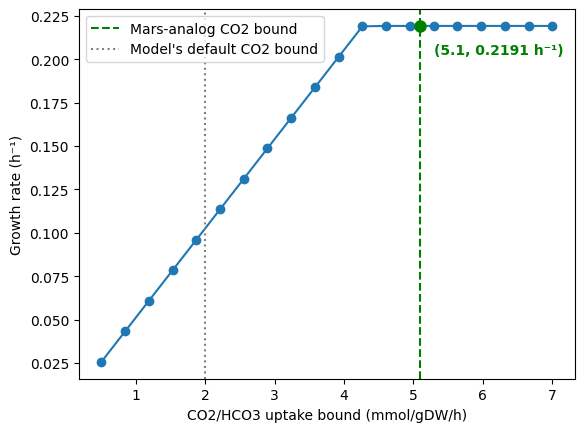

Growth rate at Mars-analog CO2 bound (5.1): 0.2191 h⁻¹


In [210]:
import numpy as np
import matplotlib.pyplot as plt

co2_values = np.linspace(0.5, 7, 20)  # mmol/gDW/h
growth_rates = []

for co2_bound in co2_values:
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -145  # Mars-analog photon bound, held fixed
        model.reactions.get_by_id("EX_co2_e").lower_bound = -co2_bound
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -co2_bound
        model.objective = "BOF"
        sol = model.optimize()
        growth_rates.append(sol.objective_value if sol.status == "optimal" else np.nan)

# compute exact growth rate at the Mars-analog CO2 bound (5.1), not interpolated
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.objective = "BOF"
    sol_mars = model.optimize()
    growth_at_mars_co2 = sol_mars.objective_value

fig, ax = plt.subplots()
ax.plot(co2_values, growth_rates, marker='o')
ax.axvline(5.1, color='green', linestyle='--', label='Mars-analog CO2 bound')
ax.axvline(1.99, color='gray', linestyle=':', label="Model's default CO2 bound")

# mark the intersection point and label it
ax.plot(5.1, growth_at_mars_co2, marker='o', color='green', markersize=8, zorder=5)
ax.annotate(f"(5.1, {growth_at_mars_co2:.4f} h⁻¹)",
            xy=(5.1, growth_at_mars_co2),
            xytext=(10,-20), textcoords='offset points',
            fontsize=10, fontweight='bold', color='green')

ax.set_xlabel("CO2/HCO3 uptake bound (mmol/gDW/h)")
ax.set_ylabel("Growth rate (h⁻¹)")
ax.legend()
plt.show()

print(f"Growth rate at Mars-analog CO2 bound (5.1): {growth_at_mars_co2:.4f} h⁻¹")

lets see what'd happen if we change the bounds for some of them

In [211]:
oxygen_rxn=model.exchanges.get_by_id("EX_o2_e")
print(oxygen_rxn.bounds)
#constraint!
#let's see what'd happen if we close the oxygen uptake 
print(f"O2 export flux: {sol.fluxes['EX_o2_e']:.4f}")
   #significant inc! 0.88 for -10 without oxygen bounded!! (oxygen is unlimited by default), so bound the o2, more controlled growth 
   
   #but what's the price for inc glu uptake? how does it affect the other active fluxes
print("----exhnages after the capped oxygen uptake------")
   for rxn in model.exchanges:
    flux= solution.fluxes[rxn.id]
    if abs(flux)> 0:
        print(f"{rxn.id:10s} {rxn.name:30s} ({rxn.bounds[0]:>7.1f}, {rxn.bounds[1]:>7.1f})  {flux:>10.4f}")

   #a constraint of FBA is that the model will always find a solution, even if it means producing unrealistic fluxes. So we need to check the fluxes to see if they make sense biologically.
   # no concept of cost or thermodynamic feasibility, so we need to check the fluxes to see if they make sense



IndentationError: unexpected indent (999388192.py, line 10)

thus, it is important to model with mars analog conditions! be aware of the model's inherited bounds vs your mars analog constraints/ conditions

In [ ]:
key_exchanges = ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_no3_e", 
                  "EX_so4_e", "EX_pi_e", "EX_o2_e", "EX_h2o_e", "EX_fe3_e"]
# add all photon exchanges separately since there are many wavelength bins

print(f"{'Reaction':<15}{'Name':<45}{'Bounds':<20}")
for rxn_id in key_exchanges:
    rxn = model.reactions.get_by_id(rxn_id)
    print(f"{rxn.id:<15}{rxn.name[:43]:<45}{str(rxn.bounds):<20}")

# separately, summarize photon bounds (min/max active wavelength range)
photon_rxns = [r for r in model.reactions if "photon" in r.id.lower()]
print(f"\n{len(photon_rxns)} photon exchange reactions, bounds range: "
      f"{min(r.bounds[0] for r in photon_rxns)} to {max(r.bounds[1] for r in photon_rxns)}")

Reaction       Name                                         Bounds              
EX_co2_e       Modeling: exchange reaction (co2_e)          (-2, 1000)          
EX_hco3_e      Modeling: exchange reaction (hco3_e)         (-1.99, 1000.0)     
EX_nh4_e       Modeling: exchange reaction (nh4_e)          (-0.0031, 1000.0)   
EX_no3_e       Modeling: exchange reaction (no3_e)          (-1.76, 1000.0)     
EX_so4_e       Modeling: exchange reaction (so4_e)          (-1000, 1000)       
EX_pi_e        Modeling: exchange reaction (pi_e)           (-0.2, 1000.0)      
EX_o2_e        Modeling: exchange reaction (o2_e)           (-100.0, 1000.0)    
EX_h2o_e       Modeling: exchange reaction (h2o_e)          (-100.0, 1000.0)    
EX_fe3_e       Modeling: exchange reaction (fe3_e)          (-0.001, 1000.0)    

15 photon exchange reactions, bounds range: -1000.0 to 1000.0


In [ ]:
#lets make it into a table for better visualization
import pandas as pd

# Define the key exchange reactions with their Mars-analog values and provenance
exchange_info = [
    {"id": "EX_co2_e",   "mars_bound": -5.1,   "source": "Literature-measured (photobioreactor CO2 uptake)"},
    {"id": "EX_hco3_e",  "mars_bound": -5.1,   "source": "Literature-measured (photobioreactor CO2 uptake)"},
    {"id": "EX_nh4_e",   "mars_bound": None,   "source": "Model default"},
    {"id": "EX_no3_e",   "mars_bound": None,   "source": "Model default"},
    {"id": "EX_so4_e",   "mars_bound": None,   "source": "Model default"},
    {"id": "EX_pi_e",    "mars_bound": None,   "source": "Model default"},
    {"id": "EX_o2_e",    "mars_bound": None,   "source": "Model default"},
    {"id": "EX_h2o_e",   "mars_bound": None,   "source": "Model default"},
    {"id": "EX_fe3_e",   "mars_bound": None,   "source": "Model default"},
    {"id": "EX_mg2_e",   "mars_bound": None,   "source": "Model default"},
    {"id": "EX_h_e",     "mars_bound": None,   "source": "Model default"},
]

rows = []
for entry in exchange_info:
    rxn = model.reactions.get_by_id(entry["id"])
    rows.append({
        "Reaction ID": rxn.id,
        "Name": rxn.name,
        "Default bounds": rxn.bounds,
        "Mars-analog lower bound": entry["mars_bound"] if entry["mars_bound"] is not None else "— (unchanged)",
        "Source": entry["source"],
    })

# Photon exchanges summarized as one row (there are many wavelength bins)
photon_rxns = [r for r in model.reactions if "photon" in r.id.lower()]
rows.append({
    "Reaction ID": f"EX_photonXXX_e (x{len(photon_rxns)})",
    "Name": "Photon absorption, all wavelength bins",
    "Default bounds": f"{min(r.bounds[0] for r in photon_rxns)} to {max(r.bounds[1] for r in photon_rxns)}",
    "Mars-analog lower bound": -145,
    "Source": "Back-derived (Broddrick et al., high-light condition, order-of-magnitude estimate)",
})

df = pd.DataFrame(rows)
df
df.to_csv("mars_analog_exchange_bounds.csv", index=False)

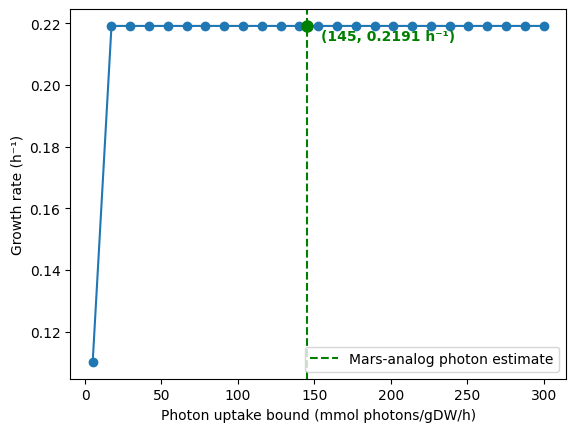

Growth rate at Mars-analog photon bound (145): 0.2191 h⁻¹


In [ ]:
photon_values = np.linspace(5, 300, 25)  # mmol photons/gDW/h
growth_rates = []

for photon_bound in photon_values:
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -photon_bound
        model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
        model.objective = "BOF"
        sol = model.optimize()
        growth_rates.append(sol.objective_value if sol.status == "optimal" else np.nan)

# exact growth rate at your Mars-analog photon estimate (145), not interpolated
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.objective = "BOF"
    sol_mars = model.optimize()
    growth_at_mars_photon = sol_mars.objective_value

fig, ax = plt.subplots()
ax.plot(photon_values, growth_rates, marker='o')
ax.axvline(145, color='green', linestyle='--', label='Mars-analog photon estimate')

ax.plot(145, growth_at_mars_photon, marker='o', color='green', markersize=8, zorder=5)
ax.annotate(f"({145}, {growth_at_mars_photon:.4f} h⁻¹)",
            xy=(145, growth_at_mars_photon),
            xytext=(10, -10), textcoords='offset points',
            fontsize=10, fontweight='bold', color='green')

ax.set_xlabel("Photon uptake bound (mmol photons/gDW/h)")
ax.set_ylabel("Growth rate (h⁻¹)")
ax.legend()
plt.show()

print(f"Growth rate at Mars-analog photon bound (145): {growth_at_mars_photon:.4f} h⁻¹")

so what's constraining the growth? lets try to find out

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.objective = "BOF"
    sol = model.optimize()

    print(f"Growth rate: {sol.objective_value:.4f}\n")
    print("Exchange reactions at (or near) their bound:")
    for r in model.exchanges:
        flux = sol.fluxes[r.id]
        lb, ub = r.bounds
        # flag reactions where flux is within 1% of hitting its lower bound
        if lb < 0 and flux <= lb * 0.99:
            print(f"  {r.id:<20} flux={flux:.4f}   bound={lb}")

Growth rate: 0.2191

Exchange reactions at (or near) their bound:
  EX_co2_e             flux=-5.1000   bound=-5.1
  EX_nh4_e             flux=-0.0031   bound=-0.0031
  EX_hco3_e            flux=-5.1000   bound=-5.1
  EX_no3_e             flux=-1.7600   bound=-1.76
  EX_photon410_e       flux=-145.0000   bound=-145
  EX_photon450_e       flux=-145.0000   bound=-145
  EX_photon470_e       flux=-145.0000   bound=-145
  EX_photon490_e       flux=-145.0000   bound=-145
  EX_photon510_e       flux=-145.0000   bound=-145
  EX_photon590_e       flux=-145.0000   bound=-145
  EX_photon610_e       flux=-145.0000   bound=-145
  EX_photon630_e       flux=-145.0000   bound=-145
  EX_photon650_e       flux=-145.0000   bound=-145
  EX_photon670_e       flux=-145.0000   bound=-145
  EX_photon690_e       flux=-145.0000   bound=-145


In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.objective = "BOF"
    sol = model.optimize()

    print(f"Growth rate: {sol.objective_value:.4f}\n")
    for rid in ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_no3_e", "EX_photon650_e"]:
        met_ids = [m.id for m in model.reactions.get_by_id(rid).metabolites]
        sp = sol.shadow_prices.get(met_ids[0], None)
        print(f"{rid:<18} shadow price: {sp}")

we've not looked into nitrogen... yet! lets check how that affect now. also notice that the shadow price of nh4 and no3 is very similar 

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_nh4_e").lower_bound = -0.35  # substantially relaxed vs. default 0.0031
    model.objective = "BOF"
    sol = model.optimize()
    print(f"Growth rate with relaxed NH4 (1.0): {sol.objective_value:.4f} h⁻¹")
    print(f"vs. current growth at NH4=0.0031: 0.2191 h⁻¹")

Growth rate with relaxed NH4 (1.0): 0.2622 h⁻¹
vs. current growth at NH4=0.0031: 0.2191 h⁻¹


okay so relaxing nitrogen does increase growth, but what's constraining now? (ps look into how to meaningfully carry this analysis)

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_nh4_e").lower_bound = -1.0
    model.objective = "BOF"
    sol = model.optimize()
    for rid in ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_photon650_e"]:
        met_id = model.reactions.get_by_id(rid).metabolites
        sp = sol.shadow_prices.get(list(met_id)[0].id, None)
        print(f"{rid:<18} shadow price: {sp}")

EX_co2_e           shadow price: -0.025671588760513956
EX_hco3_e          shadow price: -0.025671588760514077
EX_nh4_e           shadow price: -1.1819306086984715e-17
EX_photon650_e     shadow price: -9.248168431641762e-16


so now carbon's shadow price increases (more negative). it seems like the model depends on both

lets see how the carbon/ nitrogen interdependence is

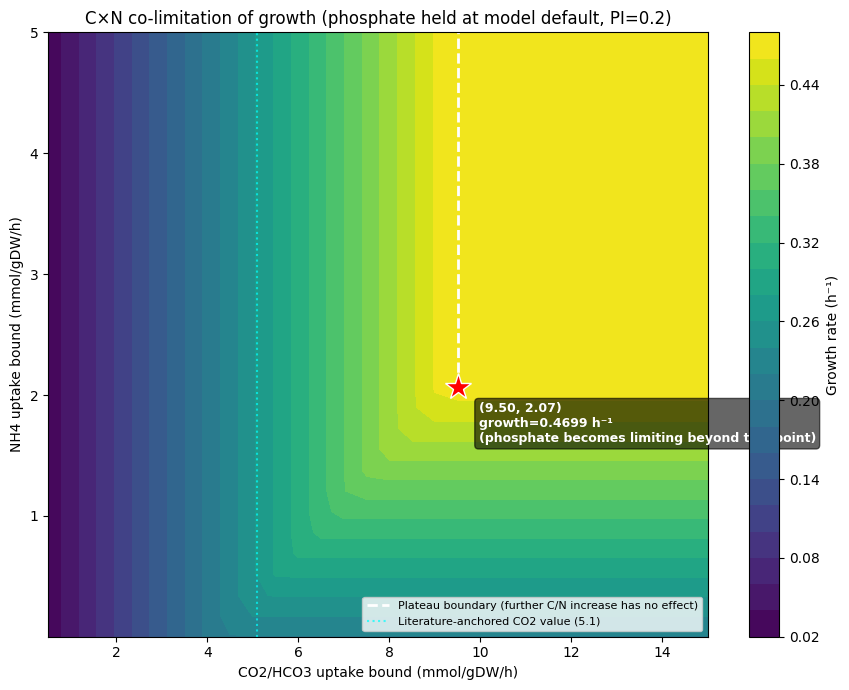

Max growth in grid: 0.4699 h⁻¹
Elbow point (minimal C,N combination reaching plateau): CO2=9.50, NH4=2.07


In [ ]:
co2_range = np.linspace(0.5, 15, 30)
nh4_range = np.linspace(0.001, 5, 30)

growth_grid = np.zeros((len(nh4_range), len(co2_range)))

for i, nh4_bound in enumerate(nh4_range):
    for j, co2_bound in enumerate(co2_range):
        with model:
            for r in model.reactions:
                if "photon" in r.id.lower():
                    r.lower_bound = -145
            model.reactions.get_by_id("EX_co2_e").lower_bound = -co2_bound
            model.reactions.get_by_id("EX_hco3_e").lower_bound = -co2_bound
            model.reactions.get_by_id("EX_nh4_e").lower_bound = -nh4_bound
            #model.reactions.get_by_id("EX_pi_e").lower_bound = -0.3
            model.objective = "BOF"
            sol = model.optimize()
            growth_grid[i, j] = sol.objective_value if sol.status == "optimal" else np.nan

max_growth = np.nanmax(growth_grid)
tolerance = 0.001  # within this of max counts as "plateaued"

# for each NH4 row, find the first CO2 value where growth reaches the plateau
co2_boundary = []
for i in range(len(nh4_range)):
    row = growth_grid[i, :]
    plateaued = np.where(row >= max_growth - tolerance)[0]
    co2_boundary.append(co2_range[plateaued[0]] if len(plateaued) > 0 else np.nan)

# find the single "elbow" point: minimal CO2+NH4 combination that first reaches the plateau
plateau_mask = growth_grid >= (max_growth - tolerance)
i_idxs, j_idxs = np.where(plateau_mask)
elbow_idx = np.argmin(co2_range[j_idxs] + nh4_range[i_idxs])  # closest-to-origin plateau point
elbow_co2 = co2_range[j_idxs[elbow_idx]]
elbow_nh4 = nh4_range[i_idxs[elbow_idx]]
elbow_growth = growth_grid[i_idxs[elbow_idx], j_idxs[elbow_idx]]

fig, ax = plt.subplots(figsize=(9, 7))
c = ax.contourf(co2_range, nh4_range, growth_grid, levels=25, cmap="viridis")
plt.colorbar(c, label="Growth rate (h⁻¹)")

# plateau boundary line: beyond this, increasing C or N alone stops helping
ax.plot(co2_boundary, nh4_range, color='white', linewidth=2, linestyle='--',
         label='Plateau boundary (further C/N increase has no effect)')

ax.axvline(5.1, color='cyan', linestyle=':', alpha=0.7, label='Literature-anchored CO2 value (5.1)')

# mark the elbow point explicitly
ax.plot(elbow_co2, elbow_nh4, marker='*', color='red', markersize=20, zorder=5,
         markeredgecolor='white', markeredgewidth=1)
ax.annotate(f"({elbow_co2:.2f}, {elbow_nh4:.2f})\ngrowth={elbow_growth:.4f} h⁻¹\n(phosphate becomes limiting beyond this point)",
            xy=(elbow_co2, elbow_nh4), xytext=(15, -40), textcoords='offset points',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

ax.set_xlabel("CO2/HCO3 uptake bound (mmol/gDW/h)")
ax.set_ylabel("NH4 uptake bound (mmol/gDW/h)")
ax.set_title("C×N co-limitation of growth (phosphate held at model default, PI=0.2)")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Max growth in grid: {max_growth:.4f} h⁻¹")
print(f"Elbow point (minimal C,N combination reaching plateau): CO2={elbow_co2:.2f}, NH4={elbow_nh4:.2f}")

at this "max" growth rate, the uptakes dont seem to increase and growth is bound at around 0.4699. then what are the bounding things atp?

In [ ]:
# find the max-growth cell, check its shadow prices
i_max, j_max = np.unravel_index(np.nanargmax(growth_grid), growth_grid.shape)
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -co2_range[j_max]
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -co2_range[j_max]
    model.reactions.get_by_id("EX_nh4_e").lower_bound = -nh4_range[i_max]
    model.objective = "BOF"
    sol = model.optimize()


    print(f"Growth: {sol.objective_value:.4f}\n")
    for rid in ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_no3_e", 
                "EX_so4_e", "EX_pi_e", "EX_fe3_e", "EX_mg2_e", "EX_photon650_e"]:
        rxn= model.reactions.get_by_id(rid)
        met_id=list(rxn.metabolites)[0].id
        sp = sol.shadow_prices.get(met_id, None)
        flux=sol.fluxes[rid]
        lb=rxn.lower_bound
        print(f"{rid:<12} flux={flux:>9.4f}  bound={lb:>9.4f}  shadow_price={sp}")

Growth: 0.4699

EX_co2_e     flux= -13.0000  bound= -13.0000  shadow_price=5.008723853972209e-15
EX_hco3_e    flux= -13.0000  bound= -13.0000  shadow_price=-2.015540693793189e-15
EX_nh4_e     flux=  -3.7933  bound=  -3.7933  shadow_price=1.934064509259025e-15
EX_no3_e     flux=  -0.1552  bound=  -1.7600  shadow_price=-0.0
EX_so4_e     flux=  -0.0640  bound=-1000.0000  shadow_price=0.0
EX_pi_e      flux=  -0.2000  bound=  -0.2000  shadow_price=-2.3493710403774006
EX_fe3_e     flux=  -0.0007  bound=  -0.0010  shadow_price=-0.0
EX_mg2_e     flux=  -0.0053  bound=-1000.0000  shadow_price=0.0
EX_photon650_e flux=-145.0000  bound=-145.0000  shadow_price=5.128728330225934e-15


phosphate it is, now lets sweep phosphate

In [ ]:

pi_values = np.linspace(0.05, 2.0, 20)
results = []

for pi_bound in pi_values:
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -145
        model.reactions.get_by_id("EX_co2_e").lower_bound = -20
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -20
        model.reactions.get_by_id("EX_nh4_e").lower_bound = -5
        model.reactions.get_by_id("EX_pi_e").lower_bound = -pi_bound
        model.objective = "BOF"
        sol = model.optimize()
        pi_sp = sol.shadow_prices.get(list(model.reactions.get_by_id("EX_pi_e").metabolites)[0].id, None)
        results.append((pi_bound, sol.objective_value, pi_sp))

for pi_bound, growth, pi_sp in results:
    print(f"PI={pi_bound:.3f}  growth={growth:.4f}  PI_shadow={pi_sp}, NH4={model.reactions.get_by_id('EX_nh4_e').lower_bound}, CO2={model.reactions.get_by_id('EX_co2_e').lower_bound}")

PI=0.050  growth=0.1175  PI_shadow=-2.349371040377249, NH4=-0.0031, CO2=-2
PI=0.153  growth=0.3586  PI_shadow=-2.3493710403772767, NH4=-0.0031, CO2=-2
PI=0.255  growth=0.5997  PI_shadow=-2.3493710403772785, NH4=-0.0031, CO2=-2
PI=0.358  growth=0.6343  PI_shadow=-5.769873572422464e-17, NH4=-0.0031, CO2=-2
PI=0.461  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=0.563  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=0.666  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=0.768  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=0.871  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=0.974  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=1.076  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=1.179  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=1.282  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=1.384  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=1.487  growth=0.6343  PI_shadow=-0.0, NH4=-0.0031, CO2=-2
PI=1.589  growth=0.6343

In [ ]:
co2_values = np.linspace(3, 15, 20)
results = []

for co2_bound in co2_values:
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -145
        model.reactions.get_by_id("EX_co2_e").lower_bound = -co2_bound
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -co2_bound
        model.reactions.get_by_id("EX_nh4_e").lower_bound = -3.97
        model.reactions.get_by_id("EX_pi_e").lower_bound = -0.4
        model.objective = "BOF"
        sol = model.optimize()
        co2_sp = sol.shadow_prices.get(list(model.reactions.get_by_id("EX_co2_e").metabolites)[0].id, None)
        results.append((co2_bound, sol.objective_value, co2_sp))

for co2_bound, growth, co2_sp in results:
    print(f"CO2={co2_bound:.3f}  growth={growth:.4f}  CO2_shadow={co2_sp}")

CO2=3.000  growth=0.1540  CO2_shadow=-0.02567158876051412
CO2=3.632  growth=0.1865  CO2_shadow=-0.025671588760514327
CO2=4.263  growth=0.2189  CO2_shadow=-0.025671588760514327
CO2=4.895  growth=0.2513  CO2_shadow=-0.025671588760514327
CO2=5.526  growth=0.2837  CO2_shadow=-0.025671588760514296
CO2=6.158  growth=0.3162  CO2_shadow=-0.02567158876051408
CO2=6.789  growth=0.3486  CO2_shadow=-0.02567158876051408
CO2=7.421  growth=0.3810  CO2_shadow=-0.02567158876051408
CO2=8.053  growth=0.4134  CO2_shadow=-0.02567158876051408
CO2=8.684  growth=0.4459  CO2_shadow=-0.02567158876051408
CO2=9.316  growth=0.4783  CO2_shadow=-0.02567158876051408
CO2=9.947  growth=0.5107  CO2_shadow=-0.025671588760514126
CO2=10.579  growth=0.5432  CO2_shadow=-0.025671588760514216
CO2=11.211  growth=0.5756  CO2_shadow=-0.025671588760514216
CO2=11.842  growth=0.6080  CO2_shadow=-0.025671588760514216
CO2=12.474  growth=0.6343  CO2_shadow=3.031317506803525e-18
CO2=13.105  growth=0.6343  CO2_shadow=-0.0
CO2=13.737  grow

final bound for N?

In [ ]:
def growth_and_shadow_at_nh4(nh4_bound):
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -145
        model.reactions.get_by_id("EX_co2_e").lower_bound = -20
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -20
        model.reactions.get_by_id("EX_pi_e").lower_bound = -0.4
        model.reactions.get_by_id("EX_nh4_e").lower_bound = -nh4_bound
        model.objective = "BOF"
        sol = model.optimize()
        met_id = list(model.reactions.get_by_id("EX_nh4_e").metabolites)[0].id
        return sol.objective_value, sol.shadow_prices.get(met_id, 0)

lo, hi = 3, 10
for _ in range(40):
    mid = (lo + hi) / 2
    growth, sp = growth_and_shadow_at_nh4(mid)
    if abs(sp) < 1e-6:
        hi = mid
    else:
        lo = mid

print(f"True NH4 requirement at final operating point: {lo:.4f} to {hi:.4f}")

True NH4 requirement at final operating point: 3.3435 to 3.3435


so when do the values converge?

In [ ]:
def bisect_breakpoint(reaction_id, fixed_bounds, lo, hi, iterations=40):
    """Find the flux bound where shadow price transitions from nonzero to ~0."""
    def shadow_at(bound):
        with model:
            for r in model.reactions:
                if "photon" in r.id.lower():
                    r.lower_bound = -fixed_bounds.get("photon", 145)
            model.reactions.get_by_id("EX_co2_e").lower_bound = -fixed_bounds.get("co2", 12.47)
            model.reactions.get_by_id("EX_hco3_e").lower_bound = -fixed_bounds.get("co2", 12.47)
            model.reactions.get_by_id("EX_nh4_e").lower_bound = -fixed_bounds.get("nh4", 3.34)
            model.reactions.get_by_id("EX_pi_e").lower_bound = -fixed_bounds.get("pi", 0.34)
            model.reactions.get_by_id(reaction_id).lower_bound = -bound
            model.objective = "BOF"
            sol = model.optimize()
            met_id = list(model.reactions.get_by_id(reaction_id).metabolites)[0].id
            return sol.shadow_prices.get(met_id, 0)

    for _ in range(iterations):
        mid = (lo + hi) / 2
        sp = shadow_at(mid)
        if abs(sp) < 1e-6:
            hi = mid
        else:
            lo = mid
    return round((lo + hi) / 2, 4)

bounds = {"nh4": 3.3435, "co2": 12.2202, "pi": 0.2671, "photon": 145}

for i in range(3):
    new_co2 = bisect_breakpoint("EX_co2_e", bounds, 3, 20)
    bounds["co2"] = new_co2
    new_pi = bisect_breakpoint("EX_pi_e", bounds, 0.05, 2)
    bounds["pi"] = new_pi
    new_nh4 = bisect_breakpoint("EX_nh4_e", bounds, 3, 10)
    bounds["nh4"] = new_nh4
    print(f"Pass {i+1}: CO2={bounds['co2']}  PI={bounds['pi']}  NH4={bounds['nh4']}")  # now indented inside the loop

print(f"\nFinal converged bounds: {bounds}")

# immediately follow with the full 9-reaction shadow-price confirmation, using these exact final bounds

Pass 1: CO2=12.2239  PI=0.2671  NH4=3.2892
Pass 2: CO2=12.2201  PI=0.2671  NH4=3.2884
Pass 3: CO2=12.2203  PI=0.2671  NH4=3.2884

Final converged bounds: {'nh4': 3.2884, 'co2': 12.2203, 'pi': 0.2671, 'photon': 145}


lets try growth rate as a criterion instead 

In [ ]:
def bisect_breakpoint_by_growth(reaction_id, fixed_bounds, lo, hi, iterations=40, step=1e-4):
    def growth_at(bound):
        with model:
            for r in model.reactions:
                if "photon" in r.id.lower():
                    r.lower_bound = -fixed_bounds.get("photon", 145)
            model.reactions.get_by_id("EX_co2_e").lower_bound = -fixed_bounds.get("co2", 12.22)
            model.reactions.get_by_id("EX_hco3_e").lower_bound = -fixed_bounds.get("co2", 12.22)
            model.reactions.get_by_id("EX_nh4_e").lower_bound = -fixed_bounds.get("nh4", 3.29)
            model.reactions.get_by_id("EX_pi_e").lower_bound = -fixed_bounds.get("pi", 0.27)
            model.reactions.get_by_id(reaction_id).lower_bound = -bound
            model.objective = "BOF"
            sol = model.optimize()
            # print(f"Growth= {sol.objective_value:.4f}")
            return sol.objective_value if sol.status == "optimal" else np.nan
            

    for _ in range(iterations):
        mid = (lo + hi) / 2
        g_mid = growth_at(mid)
        g_mid_plus = growth_at(mid + step)
        if (g_mid_plus - g_mid) < 1e-6:  # growth stopped responding -> past breakpoint
            hi = mid
        else:
            lo = mid
    return round((lo + hi) / 2, 4)


bounds = {"nh4": 3.3435, "co2": 12.2202, "pi": 0.2671, "photon": 145}

for i in range(3):
    new_co2 = bisect_breakpoint_by_growth("EX_co2_e", bounds, 3, 20)
    bounds["co2"] = new_co2
    new_pi = bisect_breakpoint_by_growth("EX_pi_e", bounds, 0.05, 2)
    bounds["pi"] = new_pi
    new_nh4 = bisect_breakpoint_by_growth("EX_nh4_e", bounds, 3, 10)
    bounds["nh4"] = new_nh4
    print(f"Pass {i+1}: CO2={bounds['co2']}  PI={bounds['pi']}  NH4={bounds['nh4']}")

print(f"\nFinal converged bounds: {bounds}")
# immediately follow with the full 9-reaction shadow-price confirmation, using these exact final bounds

Pass 1: CO2=12.2238  PI=0.2671  NH4=3.2891
Pass 2: CO2=12.2199  PI=0.2671  NH4=3.2883
Pass 3: CO2=12.2199  PI=0.2671  NH4=3.2883

Final converged bounds: {'nh4': 3.2883, 'co2': 12.2199, 'pi': 0.2671, 'photon': 145}


In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -12.2202
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -12.2202
    model.reactions.get_by_id("EX_nh4_e").lower_bound = -3.2884
    model.reactions.get_by_id("EX_pi_e").lower_bound = -0.2671
    model.objective = "BOF"
    sol = model.optimize()
    print(f"Growth rate at converged bounds: {sol.objective_value:.4f} h⁻¹")

Growth rate at converged bounds: 0.6274 h⁻¹


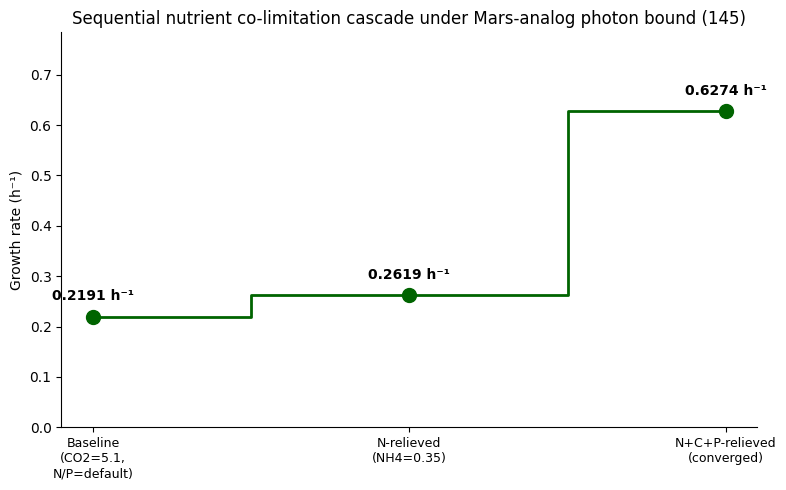

In [ ]:
import matplotlib.pyplot as plt

stages = ["Baseline\n(CO2=5.1,\nN/P=default)",
          "N-relieved\n(NH4=0.35)",
          "N+C+P-relieved\n(converged)"]
growth_values = [0.2191, 0.2619, 0.6274]

fig, ax = plt.subplots(figsize=(8, 5))
ax.step(range(len(stages)), growth_values, where='mid', linewidth=2, color='darkgreen')
ax.plot(range(len(stages)), growth_values, 'o', markersize=10, color='darkgreen', zorder=5)

for i, v in enumerate(growth_values):
    ax.annotate(f"{v:.4f} h⁻¹", (i, v), textcoords="offset points", xytext=(0, 12),
                ha='center', fontweight='bold', fontsize=10)

ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel("Growth rate (h⁻¹)")
ax.set_title("Sequential nutrient co-limitation cascade under Mars-analog photon bound (145)")
ax.set_ylim(0, max(growth_values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("nutrient_cascade_stepplot.png", dpi=300, bbox_inches='tight')
plt.show()

lets do a single figure showing the sweep for the three 

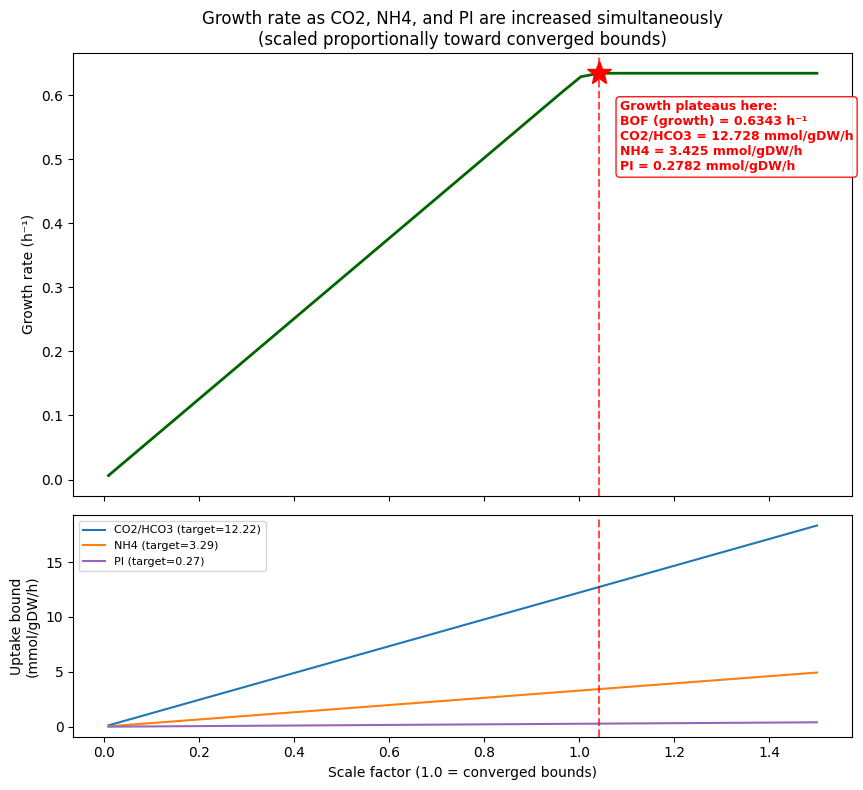

Plateau at scale=1.042: BOF=0.6343, CO2=12.728, NH4=3.425, PI=0.2782


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# converged target bounds
co2_target, nh4_target, pi_target = 12.2202, 3.2884, 0.2671

scale_factors = np.linspace(0.01, 1.5, 40)
growth_rates = []

for s in scale_factors:
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -145
        model.reactions.get_by_id("EX_co2_e").lower_bound = -co2_target * s
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -co2_target * s
        model.reactions.get_by_id("EX_nh4_e").lower_bound = -nh4_target * s
        model.reactions.get_by_id("EX_pi_e").lower_bound = -pi_target * s
        model.objective = "BOF"
        sol = model.optimize()
        growth_rates.append(sol.objective_value if sol.status == "optimal" else np.nan)

growth_rates = np.array(growth_rates)
max_growth = np.nanmax(growth_rates)
plateau_idx = np.argmax(growth_rates >= max_growth - 0.001)
plateau_scale = scale_factors[plateau_idx]

# exact bound values at the plateau point
plateau_co2 = co2_target * plateau_scale
plateau_nh4 = nh4_target * plateau_scale
plateau_pi = pi_target * plateau_scale

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(scale_factors, growth_rates, color='darkgreen', linewidth=2)
ax1.axvline(plateau_scale, color='red', linestyle='--', alpha=0.7)
ax1.plot(plateau_scale, max_growth, marker='*', color='red', markersize=18, zorder=5)
ax1.annotate(
    f"Growth plateaus here:\n"
    f"BOF (growth) = {max_growth:.4f} h⁻¹\n"
    f"CO2/HCO3 = {plateau_co2:.3f} mmol/gDW/h\n"
    f"NH4 = {plateau_nh4:.3f} mmol/gDW/h\n"
    f"PI = {plateau_pi:.4f} mmol/gDW/h",
    xy=(plateau_scale, max_growth), xytext=(15, -70), textcoords='offset points',
    fontsize=9, fontweight='bold', color='red',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.9)
)
ax1.set_ylabel("Growth rate (h⁻¹)")
ax1.set_title("Growth rate as CO2, NH4, and PI are increased simultaneously\n(scaled proportionally toward converged bounds)")

ax2.plot(scale_factors, co2_target * scale_factors, label=f"CO2/HCO3 (target={co2_target:.2f})", color='tab:blue')
ax2.plot(scale_factors, nh4_target * scale_factors, label=f"NH4 (target={nh4_target:.2f})", color='tab:orange')
ax2.plot(scale_factors, pi_target * scale_factors, label=f"PI (target={pi_target:.2f})", color='tab:purple')
ax2.axvline(plateau_scale, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel("Scale factor (1.0 = converged bounds)")
ax2.set_ylabel("Uptake bound\n(mmol/gDW/h)")
ax2.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig("joint_nutrient_scaling_growth.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plateau at scale={plateau_scale:.3f}: BOF={max_growth:.4f}, "
      f"CO2={plateau_co2:.3f}, NH4={plateau_nh4:.3f}, PI={plateau_pi:.4f}")

lets ensure that at convergence the others arent limiting

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -12.2203
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -12.2203
    model.reactions.get_by_id("EX_nh4_e").lower_bound = -3.2884
    model.reactions.get_by_id("EX_pi_e").lower_bound = -0.2671
    model.objective = "BOF"
    sol = model.optimize()

    print(f"Growth rate: {sol.objective_value:.4f} h⁻¹\n")
    for rid in ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_no3_e",
                "EX_so4_e", "EX_pi_e", "EX_fe3_e", "EX_mg2_e", "EX_photon650_e"]:
        rxn = model.reactions.get_by_id(rid)
        met_id = list(rxn.metabolites)[0].id
        sp = sol.shadow_prices.get(met_id, None)
        print(f"{rxn.id:<15} flux={sol.fluxes[rid]:>10.4f}  bound={rxn.lower_bound:>10.4f}  shadow_price={sp:.2e}")

Growth rate: 0.6274 h⁻¹

EX_co2_e        flux=  -12.2203  bound=  -12.2203  shadow_price=-1.26e-17
EX_hco3_e       flux=  -12.2203  bound=  -12.2203  shadow_price=-2.55e-17
EX_nh4_e        flux=   -3.2884  bound=   -3.2884  shadow_price=-1.24e-01
EX_no3_e        flux=   -1.7600  bound=   -1.7600  shadow_price=-1.24e-01
EX_so4_e        flux=   -0.0855  bound=-1000.0000  shadow_price=0.00e+00
EX_pi_e         flux=   -0.2671  bound=   -0.2671  shadow_price=-0.00e+00
EX_fe3_e        flux=   -0.0010  bound=   -0.0010  shadow_price=-0.00e+00
EX_mg2_e        flux=   -0.0070  bound=-1000.0000  shadow_price=0.00e+00
EX_photon650_e  flux= -145.0000  bound= -145.0000  shadow_price=4.38e-16


we can say that the shadow price of 0.124 is rly a degeneracy artifact, since increasign no3 beyond the 3.3 isnt increasing BOF anyway.

the conclusion of this part is what is limiting growth of cyanobacteria. but our true aim- to optimize is sucrose production 

# lets look for sucrose 

In [ ]:
# Find sucrose-related reactions
for rxn in model.reactions:
    if 'sucr' in rxn.id.lower() or 'sucrose' in rxn.name.lower():
        print(rxn.id, rxn.name, rxn.bounds)
        print(rxn.reaction)

SPS Sucrose phosphate synthase (0.0, 1000.0)
f6p_c + udpg_c --> h_c + suc6p_c + udp_c
SPP Sucrose-phosphate phosphatase (0.0, 1000.0)
h2o_c + suc6p_c --> pi_c + sucr_c
SUCR Sucrose hydrolyzing enzyme (0.0, 1000.0)
h2o_c + sucr_c --> fru_c + glc__D_c


we don't naturally have a sucrose export reaction, needs to be added manually

In [ ]:

with model:
    # Check if sucrose metabolite exists
    sucr = model.metabolites.get_by_id("sucr_c")  # try this first
    print(sucr)
sucr_e = Metabolite(id="sucr_e", name="Sucrose extracellular", compartment="e")
model.add_metabolites([sucr_e])

sucr_c


let's make the export rxn

In [ ]:
for met in model.metabolites:
    if 'sucr' in met.id.lower() or 'sucrose' in met.name.lower():
        print(met.id, met.name, met.compartment)

suc6p_c Sucrose 6-phosphate cytosol
sucr_c Sucrose cytosol
sucr_e Sucrose extracellular e


In [ ]:
from cobra import Reaction, Metabolite

cscB = Reaction("cscB")
cscB.name = "Sucrose export (cscB permease)"
cscB.lower_bound = 0
cscB.upper_bound = 1000
cscB.add_metabolites({
    model.metabolites.get_by_id("sucr_c"): -1,
    model.metabolites.get_by_id("h_c"): -1,
    model.metabolites.get_by_id("h_e"): 1,
    model.metabolites.get_by_id("sucr_e"): 1
})

EX_sucr = Reaction("EX_sucr_e")
EX_sucr.name = "Sucrose exchange"
EX_sucr.lower_bound = 0
EX_sucr.upper_bound = 1000
EX_sucr.add_metabolites({
    model.metabolites.get_by_id("sucr_e"): -1
})

model.add_reactions([cscB, EX_sucr])

this is bad since our model is dumping everything into sucrose at the cost of its life...
let's try to cap it by setting a minimum biomass

In [ ]:
with model: 
    model.reactions.get_by_id("BOF").lower_bound=0.03
    model.objective="EX_sucr_e"
    sol=model.optimize()
    print("Max sucrose export flux:", sol.objective_value)
    print("Biomass flux:", sol.fluxes["BOF"])

Max sucrose export flux: 0.23511607789976932
Biomass flux: 0.03


lets try with another biomass flux (similar to yeast's) and also check the oxygen production here 

In [ ]:
with model: 
    model.reactions.get_by_id("BOF").lower_bound=0.013
    model.objective="EX_sucr_e"
    sol=model.optimize()
    print("Max sucrose export flux:", sol.objective_value)
    print("Biomass flux:", sol.fluxes["BOF"])
    print(f"O2 export flux: {sol.fluxes['EX_o2_e']:.4f}")

Max sucrose export flux: 0.29030030042398197
Biomass flux: 0.013
O2 export flux: 4.2645


In [ ]:
print([m.id for m in model.metabolites if "sucrose" in m.name.lower()])
print([m.id for m in model.metabolites if "h_" in m.id in ["h_c","h_e"]])

['suc6p_c', 'sucr_c', 'sucr_e']
['h_c', 'h_e']


so what would be the sucrose flux? given the different biomasses? let's try different threshold. IMPORTANTLY, at an experimental threshold of 5.1

Max biomass flux at CO2/HCO3=5.1: 0.2191 h⁻¹


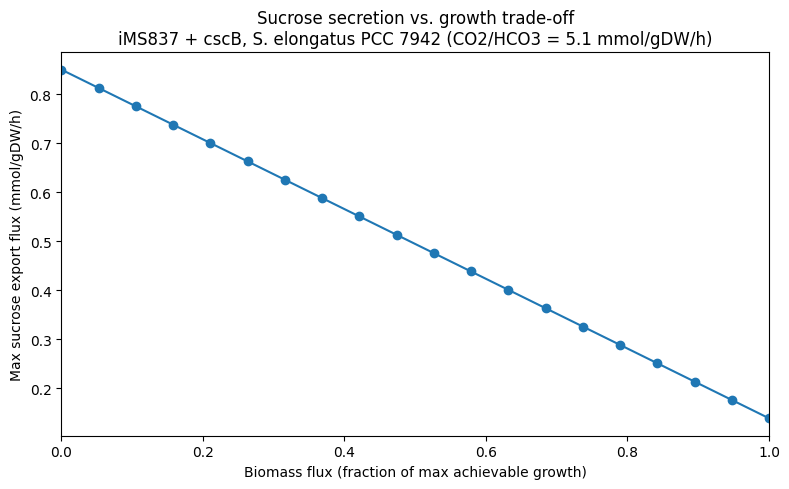

In [ ]:

# first, find max achievable biomass at these Mars-analog CO2/HCO3 bounds
with model:
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.objective = "BOF"
    sol_max = model.optimize()
    max_biomass = sol_max.objective_value

print(f"Max biomass flux at CO2/HCO3=5.1: {max_biomass:.4f} h⁻¹")

biomass_fractions_abs = np.linspace(0, max_biomass, 20)  # absolute BOF values to sweep
sucrose_fluxes = []

for bof in biomass_fractions_abs:
    with model:
        model.reactions.get_by_id("BOF").lower_bound = bof
        model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
        model.objective = "EX_sucr_e"
        sol = model.optimize()
        if sol.status == "optimal":
            sucrose_fluxes.append(sol.objective_value)
        else:
            sucrose_fluxes.append(0)

# normalize x-axis to fraction of max achievable biomass (0 to 1)
biomass_normalized = biomass_fractions_abs / max_biomass

plt.figure(figsize=(8, 5))
plt.plot(biomass_normalized, sucrose_fluxes, marker='o')
plt.xlabel("Biomass flux (fraction of max achievable growth)")
plt.ylabel("Max sucrose export flux (mmol/gDW/h)")
plt.title("Sucrose secretion vs. growth trade-off\niMS837 + cscB, S. elongatus PCC 7942 (CO2/HCO3 = 5.1 mmol/gDW/h)")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("sucrose_biomass_tradeoff.png", dpi=150)
plt.show()

Great, but what else is limiting sucrose export in this case. how can we maximize the export? (based on our previous BOF constraining analysis)

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1  # your literature-anchored value, not the growth-optimized 12.22
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.reactions.get_by_id("BOF").lower_bound = 0.013  # your actual co-culture operating point
    model.objective = "EX_sucr_e"  # or DM_sucr_c , or a combined objective if you want both sucrose and O2
    sol = model.optimize()

    print(f"Sucrose flux: {sol.objective_value:.4f}\n")
    for rid in ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_no3_e",
                "EX_so4_e", "EX_pi_e", "EX_fe3_e", "EX_mg2_e", "EX_photon650_e"]:
        rxn = model.reactions.get_by_id(rid)
        met_id = list(rxn.metabolites)[0].id
        sp = sol.shadow_prices.get(met_id, None)
        print(f"{rxn.id:<15} flux={sol.fluxes[rid]:>10.4f}  bound={rxn.lower_bound:>10.4f}  shadow_price={sp}")

Sucrose flux: 0.8078

EX_co2_e        flux=   -5.1000  bound=   -5.1000  shadow_price=-0.08333333333333322
EX_hco3_e       flux=   -5.1000  bound=   -5.1000  shadow_price=-0.08333333333333341
EX_nh4_e        flux=   -0.0031  bound=   -0.0031  shadow_price=-9.679845869371837e-17
EX_no3_e        flux=   -0.1015  bound=   -1.7600  shadow_price=-0.0
EX_so4_e        flux=   -0.0018  bound=-1000.0000  shadow_price=0.0
EX_pi_e         flux=   -0.0055  bound=   -0.2000  shadow_price=-0.0
EX_fe3_e        flux=   -0.0000  bound=   -0.0010  shadow_price=-0.0
EX_mg2_e        flux=   -0.0001  bound=-1000.0000  shadow_price=0.0
EX_photon650_e  flux=   -0.0001  bound= -145.0000  shadow_price=-0.0


In [ ]:

resources = ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_no3_e",
             "EX_so4_e", "EX_pi_e", "EX_fe3_e", "EX_mg2_e", "EX_photon650_e"]

with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "EX_sucr_e"  # or DM_sucr_c , or a combined objective if you want both sucrose and O2
    sol = model.optimize()

    rows = []
    for rid in resources:
        rxn = model.reactions.get_by_id(rid)
        met_id = list(rxn.metabolites)[0].id
        sp = sol.shadow_prices.get(met_id, 0)
        rows.append({
            "Reaction": rxn.id,
            "Flux": round(sol.fluxes[rid], 4),
            "Bound": rxn.lower_bound,
            "Shadow price": sp,
            "Binding?": "Yes" if abs(sp) > 1e-6 else "No"
        })

df = pd.DataFrame(rows)
df

,Reaction,Flux,Bound,Shadow price,Binding?
0,EX_co2_e,-5.1000,-5.1000,-8.333333e-02,Yes
1,EX_hco3_e,-5.1000,-5.1000,-8.333333e-02,Yes
2,EX_nh4_e,-0.0031,-0.0031,-1.055260e-16,No
3,EX_no3_e,-0.1015,-1.7600,-0.000000e+00,No
4,EX_so4_e,-0.0018,-1000.0000,0.000000e+00,No
5,EX_pi_e,-0.0055,-0.2000,-0.000000e+00,No
6,EX_fe3_e,-0.0000,-0.0010,-0.000000e+00,No
7,EX_mg2_e,-0.0001,-1000.0000,0.000000e+00,No
8,EX_photon650_e,-0.0001,-145.0000,-0.000000e+00,No


lets compare sucrose objective w BOF objective

Sucrose flux: 0.8078

         Reaction    Flux      Bound  Shadow price Binding?
0        EX_co2_e -5.1000    -5.1000 -8.333333e-02      Yes
1       EX_hco3_e -5.1000    -5.1000 -8.333333e-02      Yes
2        EX_nh4_e -0.0031    -0.0031 -1.055260e-16       No
3        EX_no3_e -0.1015    -1.7600 -0.000000e+00       No
4        EX_so4_e -0.0018 -1000.0000  0.000000e+00       No
5         EX_pi_e -0.0055    -0.2000 -0.000000e+00       No
6        EX_fe3_e -0.0000    -0.0010 -0.000000e+00       No
7        EX_mg2_e -0.0001 -1000.0000  0.000000e+00       No
8  EX_photon650_e -0.0001  -145.0000 -0.000000e+00       No

Growth rate: 0.6274

         Reaction     Flux      Bound  Shadow price Binding?
0        EX_co2_e -12.2203   -12.2203 -2.567159e-02      Yes
1       EX_hco3_e -12.2203   -12.2203 -2.567159e-02      Yes
2        EX_nh4_e  -3.3000    -3.3000  1.919141e-17       No
3        EX_no3_e  -1.7484    -1.7600 -0.000000e+00       No
4        EX_so4_e  -0.0855 -1000.0000  0.000000e+00

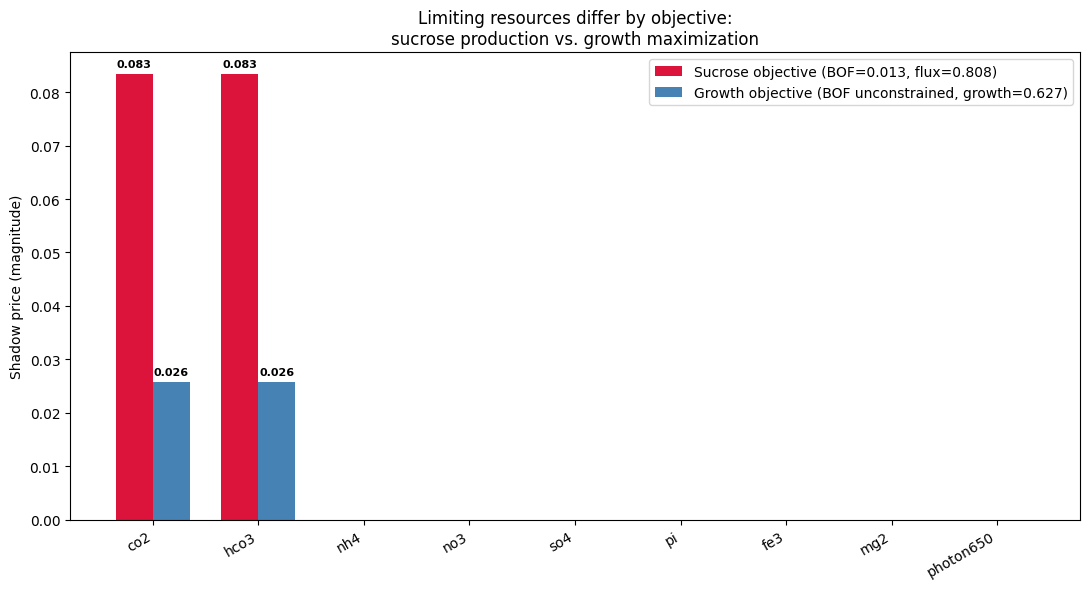


Saved: sucrose_objective_shadow_prices.csv, growth_objective_shadow_prices.csv, sucrose_vs_growth_shadow_price_comparison.png


In [ ]:

resources = ["EX_co2_e", "EX_hco3_e", "EX_nh4_e", "EX_no3_e",
             "EX_so4_e", "EX_pi_e", "EX_fe3_e", "EX_mg2_e", "EX_photon650_e"]

def get_shadow_prices(objective, bof_lower, co2_bound, nh4_bound=None, pi_bound=None):
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -145
        model.reactions.get_by_id("EX_co2_e").lower_bound = -co2_bound
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -co2_bound
        if nh4_bound is not None:
            model.reactions.get_by_id("EX_nh4_e").lower_bound = -nh4_bound
        if pi_bound is not None:
            model.reactions.get_by_id("EX_pi_e").lower_bound = -pi_bound
        model.reactions.get_by_id("BOF").lower_bound = bof_lower
        model.objective = objective
        sol = model.optimize()

        rows = []
        for rid in resources:
            rxn = model.reactions.get_by_id(rid)
            met_id = list(rxn.metabolites)[0].id
            sp = sol.shadow_prices.get(met_id, 0)
            rows.append({
                "Reaction": rxn.id,
                "Flux": round(sol.fluxes[rid], 4),
                "Bound": rxn.lower_bound,
                "Shadow price": sp,
                "Binding?": "Yes" if abs(sp) > 1e-6 else "No"
            })
        return sol.objective_value, rows

# --- Run 1: sucrose objective, at your real operating point (Mars-analog CO2, BOF capped) ---
sucrose_obj_value, sucrose_rows = get_shadow_prices(
    objective="EX_sucr_e", bof_lower=0.013, co2_bound=5.1
)
sucrose_df = pd.DataFrame(sucrose_rows)
print(f"Sucrose flux: {sucrose_obj_value:.4f}\n")
print(sucrose_df)

# --- Run 2: growth objective, at the converged nutrient-sufficient bounds ---
growth_obj_value, growth_rows = get_shadow_prices(
    objective="BOF", bof_lower=0, co2_bound=12.2203, nh4_bound=3.3, pi_bound=0.2671
)
growth_df = pd.DataFrame(growth_rows)
print(f"\nGrowth rate: {growth_obj_value:.4f}\n")
print(growth_df)

# --- Save both tables ---
sucrose_df.to_csv("sucrose_objective_shadow_prices.csv", index=False)
growth_df.to_csv("growth_objective_shadow_prices.csv", index=False)

# --- Comparison bar chart ---
labels = [r.replace("EX_", "").replace("_e", "") for r in resources]
sucrose_sp = [abs(row["Shadow price"]) for row in sucrose_rows]
growth_sp = [abs(row["Shadow price"]) for row in growth_rows]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, sucrose_sp, width, label=f'Sucrose objective (BOF=0.013, flux={sucrose_obj_value:.3f})', color='crimson')
bars2 = ax.bar(x + width/2, growth_sp, width, label=f'Growth objective (BOF unconstrained, growth={growth_obj_value:.3f})', color='steelblue')

for bar, val in zip(bars1, sucrose_sp):
    if val > 1e-6:
        ax.annotate(f"{val:.3f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, fontweight='bold')
for bar, val in zip(bars2, growth_sp):
    if val > 1e-6:
        ax.annotate(f"{val:.3f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel("Shadow price (magnitude)")
ax.set_title("Limiting resources differ by objective:\nsucrose production vs. growth maximization")
ax.legend()
plt.tight_layout()
plt.savefig("sucrose_vs_growth_shadow_price_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: sucrose_objective_shadow_prices.csv, growth_objective_shadow_prices.csv, sucrose_vs_growth_shadow_price_comparison.png")

#### now this was the model for the export, lets try accumulation of sucrose in the cytosol instead!

start by removing the rxns (if the previous step was done)

In [214]:
model.remove_reactions([
    model.reactions.get_by_id("cscB"), model.reactions.get_by_id("EX_sucr_e")])
model.remove_metabolites([model.metabolites.get_by_id("sucr_e")])

KeyError: 'cscB'

find the reactions involved with sucrose (producing sucrose)

In [215]:
[r.id for r in model.reactions if "sucr_c" in [m.id for m in r.metabolites] and r.metabolites[model.metabolites.get_by_id("sucr_c")] > 0]

['SPP']

AND the reactions consuming sucrose

In [216]:
[r.id for r in model.reactions if "sucr_c" in [m.id for m in r.metabolites]]

['SPP', 'SUCR']

In [217]:
r = model.reactions.get_by_id("SPP")
print(r.reaction)
r = model.reactions.get_by_id("SUCR")
print(r.reaction)

h2o_c + suc6p_c --> pi_c + sucr_c
h2o_c + sucr_c --> fru_c + glc__D_c


ensure that the cycle isnt futile

In [219]:
    model.objective = "SPP"
    sol = model.optimize()

    print(sol.fluxes["SPP"])
    print(sol.fluxes["SUCR"])

794.7357692307789
794.7357692307789


In [220]:
#THE NATURAL GROWTH RATE! ft the carbon input
model.objective = "BOF"
model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
sol = model.optimize()
print(sol.objective_value)

0.21912078236392443


In [221]:
with model:
    model.objective = "SPP"
    sol = model.optimize()
    print("Max sucrose accumulation flux:", sol.objective_value)
    print("Biomass flux at max sucrose:", sol.fluxes["BOF"])

Max sucrose accumulation flux: 794.7357692307689
Biomass flux at max sucrose: -6.675175812126314e-16


the above with no constraint (and i think no sink for the sucrose ) is unrealistic, lets set a bound (check the sinks for sucrose)

In [222]:
with model:
    model.reactions.get_by_id("BOF").lower_bound = 0.05  # minimum growth
    model.objective = "SPP"
    sol = model.optimize()
    print("Max sucrose accumulation flux:", sol.objective_value)
    print("Biomass flux at max sucrose:", sol.fluxes["BOF"])

Max sucrose accumulation flux: 784.1171681072353
Biomass flux at max sucrose: 0.05


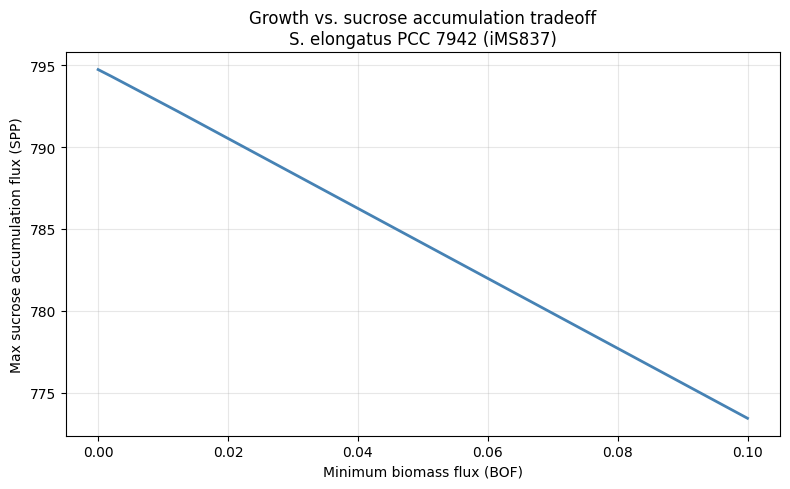

In [223]:
import numpy as np
import matplotlib.pyplot as plt

biomass_values = []
sucrose_values = []

# scan across a range of minimum biomass constraints
min_growth_range = np.linspace(0, 0.10, 50) # adjust upper bound based on your max BOF (0.102 from earlier)

with model:
    for min_growth in min_growth_range:
        model.reactions.get_by_id("BOF").lower_bound = min_growth
        model.objective = "SPP"
        sol = model.optimize()
        if sol.status == "optimal":
            biomass_values.append(min_growth)
            sucrose_values.append(sol.objective_value)
        else:
            biomass_values.append(min_growth)
            sucrose_values.append(0)

plt.figure(figsize=(8, 5))
plt.plot(biomass_values, sucrose_values, color="steelblue", linewidth=2)
plt.xlabel("Minimum biomass flux (BOF)")
plt.ylabel("Max sucrose accumulation flux (SPP)")
plt.title("Growth vs. sucrose accumulation tradeoff\nS. elongatus PCC 7942 (iMS837)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sucrose_accumulation_envelope.png", dpi=150)
plt.show()

In [ ]:
# find invertase reaction
[r.id for r in model.reactions if "inv" in r.id.lower()]

[]

In [ ]:
print(model.reactions.get_by_id("SUCR").reaction)
print(model.reactions.get_by_id("SUCR").name)
print(model.reactions.get_by_id("GLGC").reaction)
print(model.reactions.get_by_id("GLGC").name)

h2o_c + sucr_c --> fru_c + glc__D_c
Sucrose hydrolyzing enzyme
atp_c + g1p_c + h_c --> adpglc_c + ppi_c
Glucose-1-phosphate adenylyltransferase


In [ ]:
with model:
    model.reactions.get_by_id("BOF").lower_bound = 0.10
    model.objective = "SPP"
    sol = model.optimize()
    # check sucrose-related reaction fluxes
    for r in model.reactions:
        if "sucr" in r.id.lower() or "spp" in r.id.lower() or "sps" in r.id.lower() or "inv" in r.id.lower():
            print(r.id, sol.fluxes[r.id])

SPS 773.4313262154002
SPP 773.4313262154002
SUCR 773.4313262154002


SPS: Sucrose Phosphate Synthase  converts precursors (UDP-glucose + F6P) into sucrose-6-phosphate (suc6p_c). First committed step toward sucrose.
SPP:  Sucrose Phosphate Phosphatase: converts sucrose-6-phosphate into actual sucrose (sucr_c). Second and final step of sucrose synthesis.
SUCR — Sucrose hydrolyzing enzyme: the model's equivalent of invertase, breaks sucrose back into glucose and fructose. This is the futile cycle culprit we knocked out.

In [ ]:
[r.id for r in model.reactions if "glgc" in r.id.lower() or "adpglc" in r.id.lower() or "glycogen" in r.name.lower()]

['GLGC', 'GLCP4', 'GLCP3', 'GLDBRAN3', 'GLCS3']

In [ ]:
with model:
    model.reactions.get_by_id("SUCR").knock_out()   # block sucrose degradation
    model.reactions.get_by_id("GLGC").knock_out()   # block glycogen synthesis
    model.reactions.get_by_id("BOF").lower_bound = 0.013  # minimum growth
    model.objective = "SPP"
    sol = model.optimize()
    print(f"Max sucrose accumulation flux: {sol.objective_value:.4f} mmol/gDW/h")
    print(f"Biomass flux: {sol.fluxes['BOF']:.4f} h⁻¹")
    print(f"Status: {sol.status}")

Max sucrose accumulation flux: 0.0000 mmol/gDW/h
Biomass flux: 0.1309 h⁻¹
Status: optimal


In [ ]:

with model:
    model.reactions.get_by_id("SUCR").knock_out()
    model.reactions.get_by_id("GLGC").knock_out()
    
    # verify knockouts worked
    print(f"SUCR bounds: {model.reactions.get_by_id('SUCR').bounds}")
    print(f"GLGC bounds: {model.reactions.get_by_id('GLGC').bounds}")
    
    # verify objective
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "SPP"
    print(f"Objective: {model.objective}")
    print(f"BOF lower bound: {model.reactions.get_by_id('BOF').lower_bound}")
    
    sol = model.optimize()
    print(f"Status: {sol.status}")
    print(f"SPP flux: {sol.fluxes['SPP']:.4f}")
    print(f"BOF flux: {sol.fluxes['BOF']:.4f}")

SUCR bounds: (0, 0)
GLGC bounds: (0, 0)
Objective: Maximize
1.0*SPP - 1.0*SPP_reverse_a434e
BOF lower bound: 0.013
Status: optimal
SPP flux: 0.2895
BOF flux: 0.0130


as we can see, the knockouts aren't having an effect on sucorse accumulation or biomass flux, so we need to make a demand reaction for sucrose (i.e. for it being accumulated inside)

In [224]:
from cobra import Reaction

# demand reaction - acts as a sink for accumulated sucrose
sucr_demand = Reaction("DM_sucr_c")
sucr_demand.name = "Sucrose demand (intracellular accumulation)"
sucr_demand.lower_bound = 0
sucr_demand.upper_bound = 1000
sucr_demand.add_metabolites({
    model.metabolites.get_by_id("sucr_c"): -1
})
model.add_reactions([sucr_demand])

re-run the above after adding the sink reaction and observe the difference!

check the rxn rules - useful- before knocking out

In [ ]:
for rxn_id in ["SUCR", "GLGC"]:
    rxn = model.reactions.get_by_id(rxn_id)
    print(rxn.id)
    print(rxn.gene_reaction_rule)

SUCR
Synpcc7942_0397
GLGC
Synpcc7942_0603


ensure that the gene is functional

In [ ]:
gene = model.genes.get_by_id("Synpcc7942_0603")
print(gene.functional)

True


In [ ]:
with model:
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    print("Max sucrose accumulation flux:", sol.objective_value)
    print("Biomass flux at max sucrose:", sol.fluxes["BOF"])

Max sucrose accumulation flux: 0.8500000000002272
Biomass flux at max sucrose: 5.502871803315269e-14


In [ ]:
with model:
    model.objective = "DM_sucr_c"
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    sol = model.optimize()
    print("Max sucrose accumulation flux:", sol.objective_value)
    print("Biomass flux at max sucrose:", sol.fluxes["BOF"])

Max sucrose accumulation flux: 0.8078003004242886
Biomass flux at max sucrose: 0.013


In [ ]:
model.objective = "DM_sucr_c" #maximize sucrose accumulation
model.reactions.get_by_id("BOF").lower_bound = 0.013
with model:

    for gene in model.reactions.get_by_id("SUCR").genes:
        print(f"Knocking out gene: {gene.id}")
        gene.knock_out()
        print("SUCR flux:", sol.fluxes["SUCR"])

    for gene in model.reactions.get_by_id("GLGC").genes:
        print(f"Knocking out gene: {gene.id}")
        gene.knock_out()
        print("GLGC flux:", sol.fluxes["GLGC"])
    #print("DM_sucr_c:", sol.fluxes["DM_sucr_c"])

    print("SPP:", sol.fluxes["SPP"])

    print("BOF:", sol.fluxes["BOF"])

    print(sol.status)
    sol = model.optimize()
    print(sol.objective_value)

ValueError: invalid objective

weird... the knockouts dont have an effect on sucrose accumulation... lets see if those reactions ever had a flux when being optimized for sucrose accumulation

In [ ]:
model.objective = "DM_sucr_c"
glgc = model.genes.get_by_id("Synpcc7942_0603")
print(glgc.functional)
sucr = model.genes.get_by_id("Synpcc7942_0397")
print(sucr.functional)

with model:
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    sol = model.optimize()

    for rxn in ["DM_sucr_c", "SPP", "SUCR", "GLGC", "BOF"]:
        print(rxn, sol.fluxes[rxn])

True
True
DM_sucr_c 0.8078003004245623
SPP 0.8078003004245623
SUCR 0.0
GLGC 0.0
BOF 0.013


we can see from above that the sucrose flux through the two knocked out genes is zero... before knockout (???)

In [ ]:
from cobra.flux_analysis import flux_variability_analysis

fva = flux_variability_analysis(
    model,
    reaction_list=["GLGC", "SUCR", "SPP"],
    fraction_of_optimum=1.0
)

print(fva)

      minimum     maximum
GLGC   0.0000  1000.00000
SUCR   0.0000   757.38237
SPP    0.8078   758.19017


lets look at the other reactions that could be the bottleneck to sucrose production

In [ ]:
for m in ["g1p_c", "udpg_c", "suc6p_c"]:
    met = model.metabolites.get_by_id(m)
    print(f"\n{m}")
    for r in met.reactions:
        print(r.id, r.reaction)


g1p_c
PGMT g1p_c <=> g6p_c
ADPGDP adpglc_c + h2o_c --> amp_c + g1p_c + 2.0 h_c
GLCP3 glyg4n_c + 4.0 pi_c --> 4.0 g1p_c
GLCP4 bglyg4n_c + 4.0 pi_c --> 4.0 g1p_c
GALUi g1p_c + h_c + utp_c <=> ppi_c + udpg_c
G1PTT dttp_c + g1p_c + h_c --> dtdpglu_c + ppi_c
GLGC atp_c + g1p_c + h_c --> adpglc_c + ppi_c
G1PCTYT ctp_c + g1p_c + h_c --> cdpglc_c + ppi_c

udpg_c
GLUDGS_OLE_PALM 12dgr1819Z160_c + udpg_c --> glcdg1819Z160_c + h_c + udp_c
THBTGT thbpt_c + udpg_c --> gthbpt_c + h_c + udp_c
UDPGD h2o_c + 2.0 nad_c + udpg_c --> 3.0 h_c + 2.0 nadh_c + udpglcur_c
GLUDGS_OLE_HDE 12dgr1819Z1619Z_c + udpg_c --> glcdg1819Z1619Z_c + h_c + udp_c
CELLSYN glc__D_c + udpg_c --> b14glucan_c + h2o_c + h_c + udp_c
UDPSQS h_c + so3_c + udpg_c --> h2o_c + udpsq_c
UDPG4E udpg_c <=> udpgal_c
GALUi g1p_c + h_c + utp_c <=> ppi_c + udpg_c
GLUDGS_HDE_HDE 12dgr161_c + udpg_c --> glcdg161_c + h_c + udp_c
GLUDGS_HDE_PALM 12dgr1619Z160_c + udpg_c --> glcdg1619Z160_c + h_c + udp_c
OANTS 2.2481 gdpmann_c + 0.0999 udpg_c + 0.2

In [ ]:
from cobra.flux_analysis import single_gene_deletion

model.objective = "DM_sucr_c"

results = single_gene_deletion(model)
print(sort(results, key=lambda x: x["growth"])[:10])  # print top 10 genes with lowest growth

NameError: name 'sort' is not defined

lets dive in a little deepeer into the GLGC rxn, what produces sucrose-6-p (since we know this rxn competes with a precursor of s6p, g1p ig...?)

In [ ]:
met = model.metabolites.get_by_id("suc6p_c")

for r in met.reactions:
    print(r.id, r.reaction)

SPP h2o_c + suc6p_c --> pi_c + sucr_c
SPS f6p_c + udpg_c --> h_c + suc6p_c + udp_c


In [ ]:
model.objective = "DM_sucr_c" #maximize sucrose accumulation
model.reactions.get_by_id("BOF").lower_bound = 0.102
with model:
    model.reactions.get_by_id("GLUDGS_OLE_PALM").knock_out() 
    print("GLUDGS_OLE_PALM flux:", sol.fluxes["GLUDGS_OLE_PALM"])

    model.reactions.get_by_id("OANTS").knock_out() 
    print("OANTS flux:", sol.fluxes["OANTS"])

    model.reactions.get_by_id("GLUDGS_HDE_PALM").knock_out() 
    print("GLUDGS_HDE_PALM flux:", sol.fluxes["GLUDGS_HDE_PALM"])

    model.reactions.get_by_id("GLUDGS_HDE_PALM").knock_out() 
    print("GLUDGS_HDE_PALM flux:", sol.fluxes["GLUDGS_HDE_PALM"])


    # model.reactions.get_by_id("G1PTT").knock_out() 
    # print("G1PTT flux:", sol.fluxes["G1PTT"])

    # model.reactions.get_by_id("G1PTT").knock_out() 
    # print("G1PTT flux:", sol.fluxes["G1PTT"])


    print("SPP:", sol.fluxes["SPP"])

    print("BOF:", sol.fluxes["BOF"])

    print(sol.status)
    sol = model.optimize()
    print(sol.objective_value)

GLUDGS_OLE_PALM flux: 0.0004456935561000001
OANTS flux: 0.0007155878950999997
GLUDGS_HDE_PALM flux: 0.0006821536995
GLUDGS_HDE_PALM flux: 0.0006821536995
SPP: 0.28946696709063174
BOF: 0.013
infeasible
0.0005613315331924067


/Users/kevsercivek/miniforge3/envs/hinges_2/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [ ]:
model.objective = "DM_sucr_c" #maximize sucrose accumulation
model.reactions.get_by_id("BOF").lower_bound = 0.1
with model:

    for gene in model.reactions.get_by_id("G1PTT").genes:
        print(f"Knocking out gene: {gene.id}")
        gene.knock_out()
        print("G1PTT flux:", sol.fluxes["G1PTT"])

    for gene in model.reactions.get_by_id("G1PCTYT").genes:
        print(f"Knocking out gene: {gene.id}")
        gene.knock_out()
        print("G1PCTYT flux:", sol.fluxes["G1PCTYT"])

    for gene in model.reactions.get_by_id("GLGC").genes:
        print(f"Knocking out gene: {gene.id}")
        gene.knock_out()


    #udp consuming onesx
    # for gene in model.reactions.get_by_id("GLUDGS_OLE_PALM").genes:
    #     print(f"Knocking out gene: {gene.id}")
    #     gene.knock_out()
    #     print("GLUDGS_OLE_PALM flux:", sol.fluxes["GLUDGS_OLE_PALM"])

    # for gene in model.reactions.get_by_id("GLUDGS_OLE_HDE").genes:
    #     print(f"Knocking out gene: {gene.id}")
    #     gene.knock_out()
    #     print("GLUDGS_OLE_HDE flux:", sol.fluxes["GLUDGS_OLE_HDE"])

    # for gene in model.reactions.get_by_id("GLUDGS_HDE_PALM").genes:
    #     print(f"Knocking out gene: {gene.id}")
    #     gene.knock_out()
    #     print("GLUDGS_HDE_PALM flux:", sol.fluxes["GLUDGS_HDE_PALM"])

    # for gene in model.reactions.get_by_id("OANTS").genes:
    #     print(f"Knocking out gene: {gene.id}")
    #     gene.knock_out()
    #     print("OANTS flux:", sol.fluxes["OANTS"])

    # for gene in model.reactions.get_by_id("UDPGD").genes:
    #     print(f"Knocking out gene: {gene.id}")
    #     gene.knock_out()
    #     print("UDPGD flux:", sol.fluxes["UDPGD"])
    
    # for gene in model.reactions.get_by_id("GLUDGS_HDE_HDE").genes:
    #     print(f"Knocking out gene: {gene.id}")
    #     gene.knock_out()
    #     print("GLUDGS_HDE_HDE flux:", sol.fluxes["GLUDGS_HDE_HDE"])

    # for gene in model.reactions.get_by_id("CELLSYN").genes:
    #     print(f"Knocking out gene: {gene.id}")
    #     gene.knock_out()
    #     print("CELLSYN flux:", sol.fluxes["CELLSYN"])

    print("SPP:", sol.fluxes["SPP"])

    print("BOF:", sol.fluxes["BOF"])

    print(sol.status)
    sol = model.optimize()
    print(sol.objective_value)

Knocking out gene: Synpcc7942_2101
G1PTT flux: 0.0
Knocking out gene: Synpcc7942_0062
G1PCTYT flux: 0.0
Knocking out gene: Synpcc7942_0603
Knocking out gene: Synpcc7942_1083
GLUDGS_OLE_PALM flux: 0.0034284119700000015
SPP: 0.007053593005922567
BOF: 0.1
infeasible
0.007053593005922566


In [ ]:
udpg = model.metabolites.get_by_id("udpg_c")

for r in udpg.reactions:
    print(f"{r.id:15s} {sol.fluxes[r.id]:10.4f}   {r.reaction}")

SPS                 0.2895   f6p_c + udpg_c --> h_c + suc6p_c + udp_c
UDPSQS              0.0000   h_c + so3_c + udpg_c --> h2o_c + udpsq_c
GLUDGS_OLE_HDE      0.0003   12dgr1819Z1619Z_c + udpg_c --> glcdg1819Z1619Z_c + h_c + udp_c
THBTGT              0.0000   thbpt_c + udpg_c --> gthbpt_c + h_c + udp_c
UDPG4E              0.0005   udpg_c <=> udpgal_c
GLUDGS_HDE_PALM     0.0007   12dgr1619Z160_c + udpg_c --> glcdg1619Z160_c + h_c + udp_c
GLUDGS_OLE_PALM     0.0004   12dgr1819Z160_c + udpg_c --> glcdg1819Z160_c + h_c + udp_c
OANTS               0.0007   2.2481 gdpmann_c + 0.0999 udpg_c + 0.2775 udpgal_c --> 2.2481 gdp_c + 2.6255 h_c + oanticy_c + 0.3774 udp_c
UDPGD               0.0000   h2o_c + 2.0 nad_c + udpg_c --> 3.0 h_c + 2.0 nadh_c + udpglcur_c
GALUi               0.2920   g1p_c + h_c + utp_c <=> ppi_c + udpg_c
GLUDGS_HDE_HDE      0.0005   12dgr161_c + udpg_c --> glcdg161_c + h_c + udp_c
CELLSYN             0.0000   glc__D_c + udpg_c --> b14glucan_c + h2o_c + h_c + udp_c


In [ ]:
with model:
    model.reactions.get_by_id("SUCR").lower_bound = 0
    model.reactions.get_by_id("SUCR").upper_bound = 0
    model.reactions.get_by_id("GLGC").lower_bound = 0
    model.reactions.get_by_id("GLGC").upper_bound = 0
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    
    print(f"DM_sucr_c flux: {sol.fluxes['DM_sucr_c']:.4f}")
    print(f"SPP flux: {sol.fluxes['SPP']:.4f}")
    print(f"SPS flux: {sol.fluxes['SPS']:.4f}")
    print(f"SUCR flux: {sol.fluxes['SUCR']:.4f}")
    print(f"Status: {sol.status}")

DM_sucr_c flux: 0.2895
SPP flux: 0.2895
SPS flux: 0.2895
SUCR flux: 0.0000
Status: optimal


In [ ]:
model.objective = "DM_sucr_c" #maximize sucrose accumulation
model.reactions.get_by_id("BOF").lower_bound = 0.1


print("SPS", sol.fluxes["SPS"])

print("SPP:", sol.fluxes["SPP"])

print("SUCR:", sol.fluxes["SUCR"])
print("BOF:", sol.fluxes["BOF"])

print(sol.status)
sol = model.optimize()
print(sol.objective_value)

SPS 0.007053593005922567
SPP: 0.007053593005922567
SUCR: 0.0
BOF: 0.1
optimal
0.007053593005922566


it is very likely that the main issue is that because we're constraining growth, there's plenty of C so more doesnt rly need to be redirected to sucrose, its likely other things that are limiting sucrose supply (rather than udbp glu supply etc) in this case

In [ ]:
with model:
    # wild type
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol_wt = model.optimize()
    
    print("=== WILD TYPE ===")
    for r in model.reactions:
        if "photon" in r.id.lower():
            print(f"{r.id}: {sol_wt.fluxes[r.id]:.4f}")

with model:
    # knockouts
    model.reactions.get_by_id("SUCR").upper_bound = 0
    model.reactions.get_by_id("GLGC").upper_bound = 0
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol_ko = model.optimize()
    
    print("=== SUCR + GLGC KNOCKOUT ===")
    for r in model.reactions:
        if "photon" in r.id.lower():
            print(f"{r.id}: {sol_ko.fluxes[r.id]:.4f}")

=== WILD TYPE ===
EX_photon410_e: -1000.0000
EX_photon430_e: -117.6471
EX_photon450_e: 0.0000
EX_photon470_e: 0.0000
EX_photon490_e: 0.0000
EX_photon510_e: 0.0000
EX_photon530_e: 0.0000
EX_photon550_e: 0.0000
EX_photon570_e: 0.0000
EX_photon590_e: 0.0000
EX_photon610_e: 0.0000
EX_photon630_e: 0.0000
EX_photon650_e: -0.0001
EX_photon670_e: -945.1668
EX_photon690_e: -670.9150
=== SUCR + GLGC KNOCKOUT ===
EX_photon410_e: -1000.0000
EX_photon430_e: -117.6471
EX_photon450_e: 0.0000
EX_photon470_e: 0.0000
EX_photon490_e: 0.0000
EX_photon510_e: 0.0000
EX_photon530_e: 0.0000
EX_photon550_e: 0.0000
EX_photon570_e: 0.0000
EX_photon590_e: 0.0000
EX_photon610_e: 0.0000
EX_photon630_e: 0.0000
EX_photon650_e: -0.0001
EX_photon670_e: -945.1668
EX_photon690_e: -670.9150


since photon consumption is the same in both of these cases... it would mean that photon is the limiting factor... if it is so, lets test our knockouts in 'unlimited' photon supply

In [ ]:
with model:
    # unlimited photons
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    print(f"Unlimited photons sucrose flux: {sol.fluxes['DM_sucr_c']:.4f}")

Unlimited photons sucrose flux: 0.2895


In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("SUCR").upper_bound = 0
    model.reactions.get_by_id("GLGC").upper_bound = 0
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    print(f"Unlimited photons + knockouts sucrose flux: {sol.fluxes['DM_sucr_c']:.4f}")

Unlimited photons + knockouts sucrose flux: 0.2895


its the same... so lets check other possible bottlenecks, like carbon fixation? 

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    
    print(f"CO2 uptake: {sol.fluxes['EX_co2_e']:.4f}")
    print(f"HCO3 uptake: {sol.fluxes['EX_hco3_e']:.4f}")
    print(f"Photon 410: {sol.fluxes['EX_photon410_e']:.4f}")
    print(f"Photon 670: {sol.fluxes['EX_photon670_e']:.4f}")

CO2 uptake: -1.9900
HCO3 uptake: -1.9900
Photon 410: -1000.0000
Photon 670: -945.1668


In [ ]:
print(f"CO2 bounds: {model.reactions.get_by_id('EX_co2_e').bounds}")
print(f"HCO3 bounds: {model.reactions.get_by_id('EX_hco3_e').bounds}")

CO2 bounds: (-1.99, 1000.0)
HCO3 bounds: (-1.99, 1000.0)


In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("EX_co2_e").lower_bound = -1000
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -1000
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    print(f"Sucrose flux: {sol.fluxes['DM_sucr_c']:.4f}")
    print(f"CO2 uptake: {sol.fluxes['EX_co2_e']:.4f}")
    print(f"HCO3 uptake: {sol.fluxes['EX_hco3_e']:.4f}")

Sucrose flux: 16.3310
CO2 uptake: -96.4832
HCO3 uptake: -99.9951


In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("EX_co2_e").lower_bound = -1000
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -1000
    model.reactions.get_by_id("SUCR").knock_out()
    model.reactions.get_by_id("GLGC").knock_out()
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    print(f"Sucrose flux: {sol.fluxes['DM_sucr_c']:.4f}")
    print(f"CO2 uptake: {sol.fluxes['EX_co2_e']:.4f}")
    print(f"SUCR flux: {sol.fluxes['SUCR']:.4f}")
    print(f"GLGC flux: {sol.fluxes['GLGC']:.4f}")
    print(f"BOF flux: {sol.fluxes['BOF']:.4f}")

    print("----")
    # check all sucrose related fluxes
    for r in model.reactions:
        if any(m.id in ["sucr_c", "suc6p_c"] for m in r.metabolites):
            print(f"{r.id}: {r.name}: {sol.fluxes[r.id]:.4f} bounds: {r.bounds}")

Sucrose flux: 16.3310
CO2 uptake: -96.4832
SUCR flux: 0.0000
GLGC flux: 0.0000
BOF flux: 0.0130
----
SPS: Sucrose phosphate synthase: 16.3310 bounds: (0.0, 1000.0)
SPP: Sucrose-phosphate phosphatase: 16.3310 bounds: (0.0, 1000.0)
SUCR: Sucrose hydrolyzing enzyme: 0.0000 bounds: (0, 0)
DM_sucr_c: Sucrose demand (intracellular accumulation): 16.3310 bounds: (0, 1000)


lets try overexpression

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("EX_co2_e").lower_bound = -1000
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -1000
    model.reactions.get_by_id("SUCR").knock_out()
    model.reactions.get_by_id("GLGC").knock_out()
    model.reactions.get_by_id("SPS").upper_bound = 2000  # overexpression
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    print(f"Sucrose flux with SPS overexpression: {sol.fluxes['DM_sucr_c']:.4f}")

Sucrose flux with SPS overexpression: 16.3310


In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("EX_co2_e").lower_bound = -1000
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -1000
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    
    # check SPS precursors
    for m in model.reactions.get_by_id("SPS").metabolites:
        print(f"{m.id}: {m.name}")
        # find reactions producing this metabolite
        for r in model.reactions:
            if m in r.metabolites and r.metabolites[m] > 0:
                print(f"  produced by: {r.id} at flux: {sol.fluxes[r.id]:.4f}")

f6p_c: D-Fructose 6-phosphate
  produced by: PGI at flux: -16.3335
  produced by: TALA at flux: -66.5193
  produced by: TKT2 at flux: -66.4536
  produced by: HEX7 at flux: 0.0000
  produced by: FBP at flux: 165.7114
  produced by: MAN6PI at flux: -0.0018
  produced by: G6PDA at flux: 0.0000
h_c: H+
  produced by: MSBENZMT at flux: 0.0000
  produced by: GTPCI at flux: 0.0000
  produced by: MTHFC at flux: 0.0059
  produced by: GARFT at flux: 0.0023
  produced by: PRAGSr at flux: 0.0025
  produced by: GLNS at flux: 0.0214
  produced by: SHKK at flux: 0.0051
  produced by: G1PACT at flux: 0.0014
  produced by: PNTK at flux: 0.0000
  produced by: LEUabcpp at flux: 0.0000
  produced by: U23GAAT2 at flux: 0.0001
  produced by: IMPD at flux: 0.0014
  produced by: GCALDDy at flux: 0.0000
  produced by: AIRC2 at flux: 0.0025
  produced by: HEMEAS at flux: 0.0000
  produced by: HISTDb at flux: 0.0011
  produced by: SPS at flux: 16.3310
  produced by: ADCL at flux: 0.0000
  produced by: Cobalt2abc

In [ ]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -1000
    model.reactions.get_by_id("EX_co2_e").lower_bound = -1000
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -1000
    model.reactions.get_by_id("SUCR").knock_out()
    model.reactions.get_by_id("GLGC").knock_out()
    model.reactions.get_by_id("GALUi").upper_bound = 2000  # overexpression
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"
    sol = model.optimize()
    print(f"Sucrose flux: {sol.fluxes['DM_sucr_c']:.4f}")
    print(f"GALUi flux: {sol.fluxes['GALUi']:.4f}")
    print(f"SPS flux: {sol.fluxes['SPS']:.4f}")
    print(f"BOF flux: {sol.fluxes['BOF']:.4f}")

Sucrose flux: 16.3310
GALUi flux: 16.3335
SPS flux: 16.3310
BOF flux: 0.0130


In [ ]:
for m in model.reactions.get_by_id("GALUi").metabolites:
    if model.reactions.get_by_id("GALUi").metabolites[m] < 0:  # consumed
        print(f"Substrate: {m.id}: {m.name}")
        for r in model.reactions:
            if m in r.metabolites and r.metabolites[m] > 0:
                if abs(sol.fluxes[r.id]) > 0.001:
                    print(f"  produced by: {r.id}: {r.name}: {sol.fluxes[r.id]:.4f}")

Substrate: g1p_c: D-Glucose 1-phosphate
Substrate: h_c: H+
  produced by: MTHFC: Methenyltetrahydrofolate cyclohydrolase: 0.0059
  produced by: GARFT: Phosphoribosylglycinamide formyltransferase: 0.0023
  produced by: PRAGSr: Phosphoribosylglycinamide synthase: 0.0025
  produced by: GLNS: Glutamine synthetase: 0.0214
  produced by: SHKK: Shikimate kinase: 0.0051
  produced by: G1PACT: Glucosamine-1-phosphate N-acetyltransferase: 0.0014
  produced by: IMPD: IMP dehydrogenase: 0.0014
  produced by: AIRC2: Phosphoribosylaminoimidazole carboxylase: 0.0025
  produced by: HISTDb: Histidinol dehydrogenase (histidine forming): 0.0011
  produced by: SPS: Sucrose phosphate synthase: 16.3310
  produced by: H4THDPS: 4-hydroxy-tetrahydrodipicolinate synthase: 0.0031
  produced by: HISTDa: Histidinol dehydrogenase step (Histidinal forming): 0.0011
  produced by: GLYCK: Glycerate kinase: 0.9854
  produced by: CS: Citrate synthase: 0.0153
  produced by: G3PD2: Glycerol-3-phosphate dehydrogenase (NADP)

In [ ]:
g1p = model.metabolites.get_by_id("g1p_c")
print("Reactions producing g1p_c:")
for r in model.reactions:
    if g1p in r.metabolites and r.metabolites[g1p] > 0:
        print(f"  {r.id}: {r.name}: {sol.fluxes[r.id]:.4f}")

Reactions producing g1p_c:
  ADPGDP: ADP-glucose diphosphatase: 0.0000
  GLCP4: glycogen phosphorylase 4 units: 0.0000
  GLCP3: glycogen phosphorylase 4 units: 0.0000


so what produces the G1P???

In [ ]:
g1p = model.metabolites.get_by_id("g1p_c")
print("ALL reactions involving g1p_c:")
for r in model.reactions:
    if g1p in r.metabolites:
        print(f"  {r.id}: {r.name}: flux={sol.fluxes[r.id]:.4f} stoich={r.metabolites[g1p]}")

ALL reactions involving g1p_c:
  G1PTT: Glucose-1-phosphate thymidylyltransferase: flux=0.0000 stoich=-1
  GALUi: UTP-glucose-1-phosphate uridylyltransferase (irreversible): flux=16.3335 stoich=-1
  PGMT: Phosphoglucomutase: flux=-16.3335 stoich=-1
  G1PCTYT: D-glucose cytidylyltransferase: flux=0.0000 stoich=-1
  GLGC: Glucose-1-phosphate adenylyltransferase: flux=0.0000 stoich=-1
  ADPGDP: ADP-glucose diphosphatase: flux=0.0000 stoich=1
  GLCP4: glycogen phosphorylase 4 units: flux=0.0000 stoich=4.0
  GLCP3: glycogen phosphorylase 4 units: flux=0.0000 stoich=4.0


In [ ]:
print(f"PGMT bounds: {model.reactions.get_by_id('PGMT').bounds}")
print(f"PGMT flux: {sol.fluxes['PGMT']:.4f}")
print(f"PGMT reaction: {model.reactions.get_by_id('PGMT').reaction}")

# check g6p_c producers
g6p = model.metabolites.get_by_id("g6p_c")
print("\nReactions producing g6p_c:")
for r in model.reactions:
    if g6p in r.metabolites and r.metabolites[g6p] > 0:
        if abs(sol.fluxes[r.id]) > 0.001:
            print(f"  {r.id}: {r.name}: {sol.fluxes[r.id]:.4f}")

PGMT bounds: (-1000.0, 1000.0)
PGMT flux: -16.3335
PGMT reaction: g1p_c <=> g6p_c

Reactions producing g6p_c:
  PGMT: Phosphoglucomutase: -16.3335


In [ ]:
g6p = model.metabolites.get_by_id("g6p_c")
print("ALL reactions involving g6p_c:")
for r in model.reactions:
    if g6p in r.metabolites:
        if abs(sol.fluxes[r.id]) > 0.001:
            print(f"  {r.id}: {r.name}: flux={sol.fluxes[r.id]:.4f} stoich={r.metabolites[g6p]}")

ALL reactions involving g6p_c:
  PGI: Glucose-6-phosphate isomerase: flux=-16.3335 stoich=-1
  PGMT: Phosphoglucomutase: flux=-16.3335 stoich=1


#### let's re-try knockouts following the extensive nutrient consumption analysis

In [ ]:
from cobra.flux_analysis import single_gene_deletion

with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.objective = "DM_sucr_c"  # accumulation strategy
    results_accumulation = single_gene_deletion(model)
results_sorted = results_accumulation.sort_values("growth", ascending=False)
results_accumulation.sort_values("growth", ascending=False).to_csv("knockout_screen_accumulation.csv")
print("Saved: knockout_screen_accumulation.csv")
# repeat with objective = "EX_sucr_e" for the export/CscB strategy, so you have both

Saved: knockout_screen_accumulation.csv


In [ ]:
genes_of_interest = ["Synpcc7942_0808"]  # the full-abolisher — check this one first

# the ~15 partial reducers — pull their exact IDs from your results dataframe
partial_reducers = results_sorted[(results_sorted["growth"] > 0.375) & (results_sorted["growth"] < 0.376)]
genes_of_interest += [list(g)[0] for g in partial_reducers["ids"]]

for gene_id in genes_of_interest:
    gene = model.genes.get_by_id(gene_id)
    print(f"\nGene: {gene.id}  |  Name: {gene.name}")
    for rxn in gene.reactions:
        print(f"  Reaction: {rxn.id} — {rxn.name}")
        print(f"  GPR: {rxn.gene_reaction_rule}")


Gene: Synpcc7942_0808  |  Name: 
  Reaction: SPS — Sucrose phosphate synthase
  GPR: Synpcc7942_0808
  Reaction: SPP — Sucrose-phosphate phosphatase
  GPR: Synpcc7942_0808

Gene: Synpcc7942_2257  |  Name: 
  Reaction: NDH-1(1)um — NAD(P)H dehydrogenase (plastoquinone-8 & 4 protons)( Thylakoid)
  GPR: Synpcc7942_1343 and Synpcc7942_1415 and Synpcc7942_1180 and Synpcc7942_1346 and Synpcc7942_1345 and Synpcc7942_1743 and Synpcc7942_1344 and Synpcc7942_1182 and Synpcc7942_1181 and Synpcc7942_0413 and Synpcc7942_2234 and Synpcc7942_1982 and Synpcc7942_2487 and Synpcc7942_2257 and Synpcc7942_1908 and Synpcc7942_1106 and Synpcc7942_0668 and Synpcc7942_0491 and Synpcc7942_1439 and Synpcc7942_1977
  Reaction: NDH-1(3)um — NAD(P)H dehydrogenase, carbon dioxide coupled (plastoquinone-8 & 4 protons)( Thylakoid)
  GPR: Synpcc7942_1343 and Synpcc7942_1415 and Synpcc7942_1180 and Synpcc7942_1346 and Synpcc7942_1345 and Synpcc7942_1743 and Synpcc7942_1344 and Synpcc7942_1182 and Synpcc7942_1181 and S

In [ ]:
summary_table = pd.concat([
    partial_reducers.assign(category="Partial reduction (~53%)"),
    results_sorted[results_sorted["growth"] == 0].assign(category="Complete abolishment")
])
summary_table[["ids", "growth", "category"]].to_csv("sucrose_knockout_targets.csv", index=False)

above, we obtained a list of genes who's knockout had no effect, reduce sucrose secretion or so. but we dont see any sucrose INC knockouts- that has to most probably do with the way the solver works, it always tries to find the max answer since youre optimizing for that

In [235]:
with model:
    for r in model.reactions:
        if "photon" in r.id.lower():
            r.lower_bound = -145
    model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
    model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
    model.reactions.get_by_id("BOF").lower_bound = 0.013
    model.reactions.get_by_id("BOF").upper_bound = 0.013
    
    #lets try constraining other nutrients to see if we can get a higher sucrose flux
    model.reactions.get_by_id("EX_nh4_e").lower_bound = -3.1
    model.reactions.get_by_id("EX_pi_e").lower_bound = -0.2

    model.objective = "BOF"  # explicit, not inherited from a stale earlier cell
    fva_wt = flux_variability_analysis(model, reaction_list=["DM_sucr_c"], fraction_of_optimum=0.99)
    print("WT sucrose flux range at BOF=0.013:")
    print(fva_wt)

wt_min = fva_wt.loc["DM_sucr_c", "minimum"]

results = []
for gene in model.genes:
    with model:
        for r in model.reactions:
            if "photon" in r.id.lower():
                r.lower_bound = -145
        model.reactions.get_by_id("EX_co2_e").lower_bound = -5.1
        model.reactions.get_by_id("EX_hco3_e").lower_bound = -5.1
        model.reactions.get_by_id("BOF").lower_bound = 0.013
        model.reactions.get_by_id("BOF").upper_bound = 0.013
        
        #lets try constraining other nutrients to see if we can get a higher sucrose flux
        model.reactions.get_by_id("EX_nh4_e").lower_bound = -3.1
        model.reactions.get_by_id("EX_pi_e").lower_bound = -0.2
        model.objective = "BOF"
        gene.knock_out()
        sol = model.optimize()
        if sol.status != "optimal":
            results.append({"gene": gene.id, "status": "infeasible"})
            continue
        fva = flux_variability_analysis(model, reaction_list=["DM_sucr_c"], fraction_of_optimum=0.99)
        results.append({
            "gene": gene.id,
            "status": "optimal",
            "sucrose_min": fva.loc["DM_sucr_c", "minimum"],
            "sucrose_max": fva.loc["DM_sucr_c", "maximum"]
        })

df = pd.DataFrame(results)
df.to_csv("gene_knockout_sucrose_FVA.csv", index=False)

forced_producers = df[(df["status"] == "optimal") & (df["sucrose_min"] > wt_min + 1e-6)]
print(forced_producers.sort_values("sucrose_min", ascending=False))

WT sucrose flux range at BOF=0.013:
           minimum  maximum
DM_sucr_c      0.0   0.8078


/Users/kevsercivek/miniforge3/envs/hinges_2/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/kevsercivek/miniforge3/envs/hinges_2/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/kevsercivek/miniforge3/envs/hinges_2/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/kevsercivek/miniforge3/envs/hinges_2/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/kevsercivek/miniforge3/envs/hinges_2/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/Users/kevsercivek/minifo

Empty DataFrame
Columns: [gene, status, sucrose_min, sucrose_max]
Index: []


In [237]:
print(f"Total genes tested: {len(df)}")
print(f"Status counts:\n{df['status'].value_counts()}")
print(f"\nWT min sucrose flux: {wt_min}")
print(f"\nSucrose_min distribution among optimal genes:")
print(df[df['status'] == 'optimal']['sucrose_min'].describe())
print(f"\nTop 10 by sucrose_min:")
print(df[df['status'] == 'optimal'].sort_values('sucrose_min', ascending=False).head(10))

Total genes tested: 837
Status counts:
status
optimal       522
infeasible    315
Name: count, dtype: int64

WT min sucrose flux: 0.0

Sucrose_min distribution among optimal genes:
count    522.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: sucrose_min, dtype: float64

Top 10 by sucrose_min:
                gene   status  sucrose_min  sucrose_max
1    Synpcc7942_0707  optimal          0.0       0.8078
582  Synpcc7942_0023  optimal          0.0       0.8078
580  Synpcc7942_1235  optimal          0.0       0.8078
577  Synpcc7942_0098  optimal          0.0       0.8078
576  Synpcc7942_0603  optimal          0.0       0.8078
573  Synpcc7942_1939  optimal          0.0       0.8078
572  Synpcc7942_0245  optimal          0.0       0.8078
570  Synpcc7942_2252  optimal          0.0       0.8078
568  Synpcc7942_1992  optimal          0.0       0.8078
564  Synpcc7942_0307  optimal          0.0       0.8078
